# Lección 1.3 · Composición de secuencias: GC, GC skew y el origen de replicación

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-01-biologia-molecular/1.3_composicion_gc_skew.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 1 — Biología molecular para bioinformáticos** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~3 horas | Introductorio–intermedio | Lecciones 0.1–0.3 y 1.1–1.2 |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Describir** la replicación bidireccional de un cromosoma bacteriano circular: origen (*oriC*), terminación (*ter*),
   hebra adelantada y hebra retrasada.
2. **Explicar** por qué la replicación deja una "cicatriz" química en la composición del ADN: el **sesgo GC**
   (*GC skew*).
3. **Calcular** el sesgo GC por ventanas y el **sesgo acumulado**, a mano y con `numpy`.
4. **Predecir** el origen y la terminación de replicación del genoma de *Escherichia coli* sin hacer un solo
   experimento de laboratorio, y **comparar** la predicción con la anotación oficial.
5. **Decidir** el tamaño de ventana adecuado usando el ruido binomial ($1/\sqrt{m}$).
6. **Medir** la abundancia relativa de dinucleótidos $\rho_{XY}$ y **descubrir** la supresión de CpG en SARS-CoV-2.

## 🗺️ Mapa de la clase

1. Un cromosoma circular que se copia en dos direcciones
2. La cicatriz de la replicación: de dónde sale el sesgo G/C
3. 🧪 Simulación: ver nacer el sesgo en un genoma de juguete
4. El sesgo GC: definición, cálculo a mano y en código
5. 🧪 Experimento: encontrar *oriC* en el genoma de *E. coli*
6. El genoma como un reloj: mapa circular
7. ¿Qué tan grande debe ser la ventana? Señal contra ruido
8. Más allá de las bases sueltas: dinucleótidos y la supresión de CpG
9. Ejercicios, resumen y lecturas

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import gzip, io
import plotly.graph_objects as go
from plotly.subplots import make_subplots

try:
    import Bio
except ImportError:
    %pip install -q biopython
    import Bio
from Bio import SeqIO, Entrez
Entrez.email = "su.correo@ejemplo.com"     # ← escriba aquí su correo (el NCBI lo pide)
RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

Entorno listo ✔  |  Colab: False


## 1. Un cromosoma circular que se copia en dos direcciones

El cromosoma de *Escherichia coli* es una sola molécula de ADN **circular** de unos 4.6 millones de pares de bases.
Antes de dividirse, la bacteria debe copiarlo completo, y lo hace de una manera muy ordenada:

* La copia **empieza siempre en el mismo lugar**, una secuencia especial llamada **origen de replicación**, *oriC*.
  Allí la proteína DnaA abre la doble hélice.
* Desde *oriC* salen **dos maquinarias de copia** (dos **horquillas de replicación**) que avanzan en **direcciones
  opuestas**, como dos personas que parten del mismo punto de una pista circular y caminan una hacia la izquierda y
  otra hacia la derecha.
* Las dos horquillas **se encuentran en el lado opuesto** del círculo, en la **región de terminación**, *ter*.

Así el cromosoma queda dividido en dos mitades, llamadas **replicores**: cada una es copiada por una sola horquilla.

### Un cálculo a mano: ¿cuánto tarda la copia?

Una horquilla bacteriana avanza aproximadamente a **1 000 nucleótidos por segundo**. Si el genoma mide
$L \approx 4\,640\,000$ pb y hay **dos** horquillas trabajando al mismo tiempo, cada una copia la mitad:

$$
t \;\approx\; \frac{L/2}{v} \;=\; \frac{2\,320\,000\ \text{nt}}{1\,000\ \text{nt/s}} \;=\; 2\,320\ \text{s} \;\approx\; 39\ \text{minutos}
$$

| Símbolo | Significado |
|---|---|
| $L$ | longitud del cromosoma (pb) |
| $L/2$ | lo que copia **cada** horquilla (un replicor) |
| $v$ | velocidad de una horquilla (nt/s) |
| $t$ | tiempo para copiar el cromosoma completo |

¡Cerca de 40 minutos, que es justamente lo que se mide en el laboratorio! Si hubiera una sola horquilla, la copia
tardaría el doble.

### Hebra adelantada y hebra retrasada

Aquí aparece un detalle que será la clave de toda la clase. La ADN polimerasa **sólo sabe escribir en una
dirección**: agrega nucleótidos al extremo 3' de la cadena nueva (síntesis 5'→3'). Pero las dos hebras de la doble
hélice son **antiparalelas**. Resultado:

* Una de las hebras nuevas se sintetiza **de corrido**, en la misma dirección en que avanza la horquilla: es la
  **hebra adelantada** (*leading strand*).
* La otra hebra nueva debe sintetizarse **"de reversa"**, en pedacitos de 1 000–2 000 nt llamados **fragmentos de
  Okazaki**, que luego se unen: es la **hebra retrasada** (*lagging strand*).

Es como pintar las dos rayas de una carretera mientras se avanza en un solo sentido, con un pincel que sólo pinta
"hacia adelante" en una raya y "hacia atrás" en la otra: en la segunda hay que adelantarse un tramo, pintar hacia
atrás, adelantarse otro tramo, y así sucesivamente.

Mientras espera a que se inicie el siguiente fragmento de Okazaki, **la hebra molde de la hebra retrasada queda
expuesta como cadena sencilla**. Recuerde este detalle: el ADN de cadena sencilla es químicamente mucho más frágil.

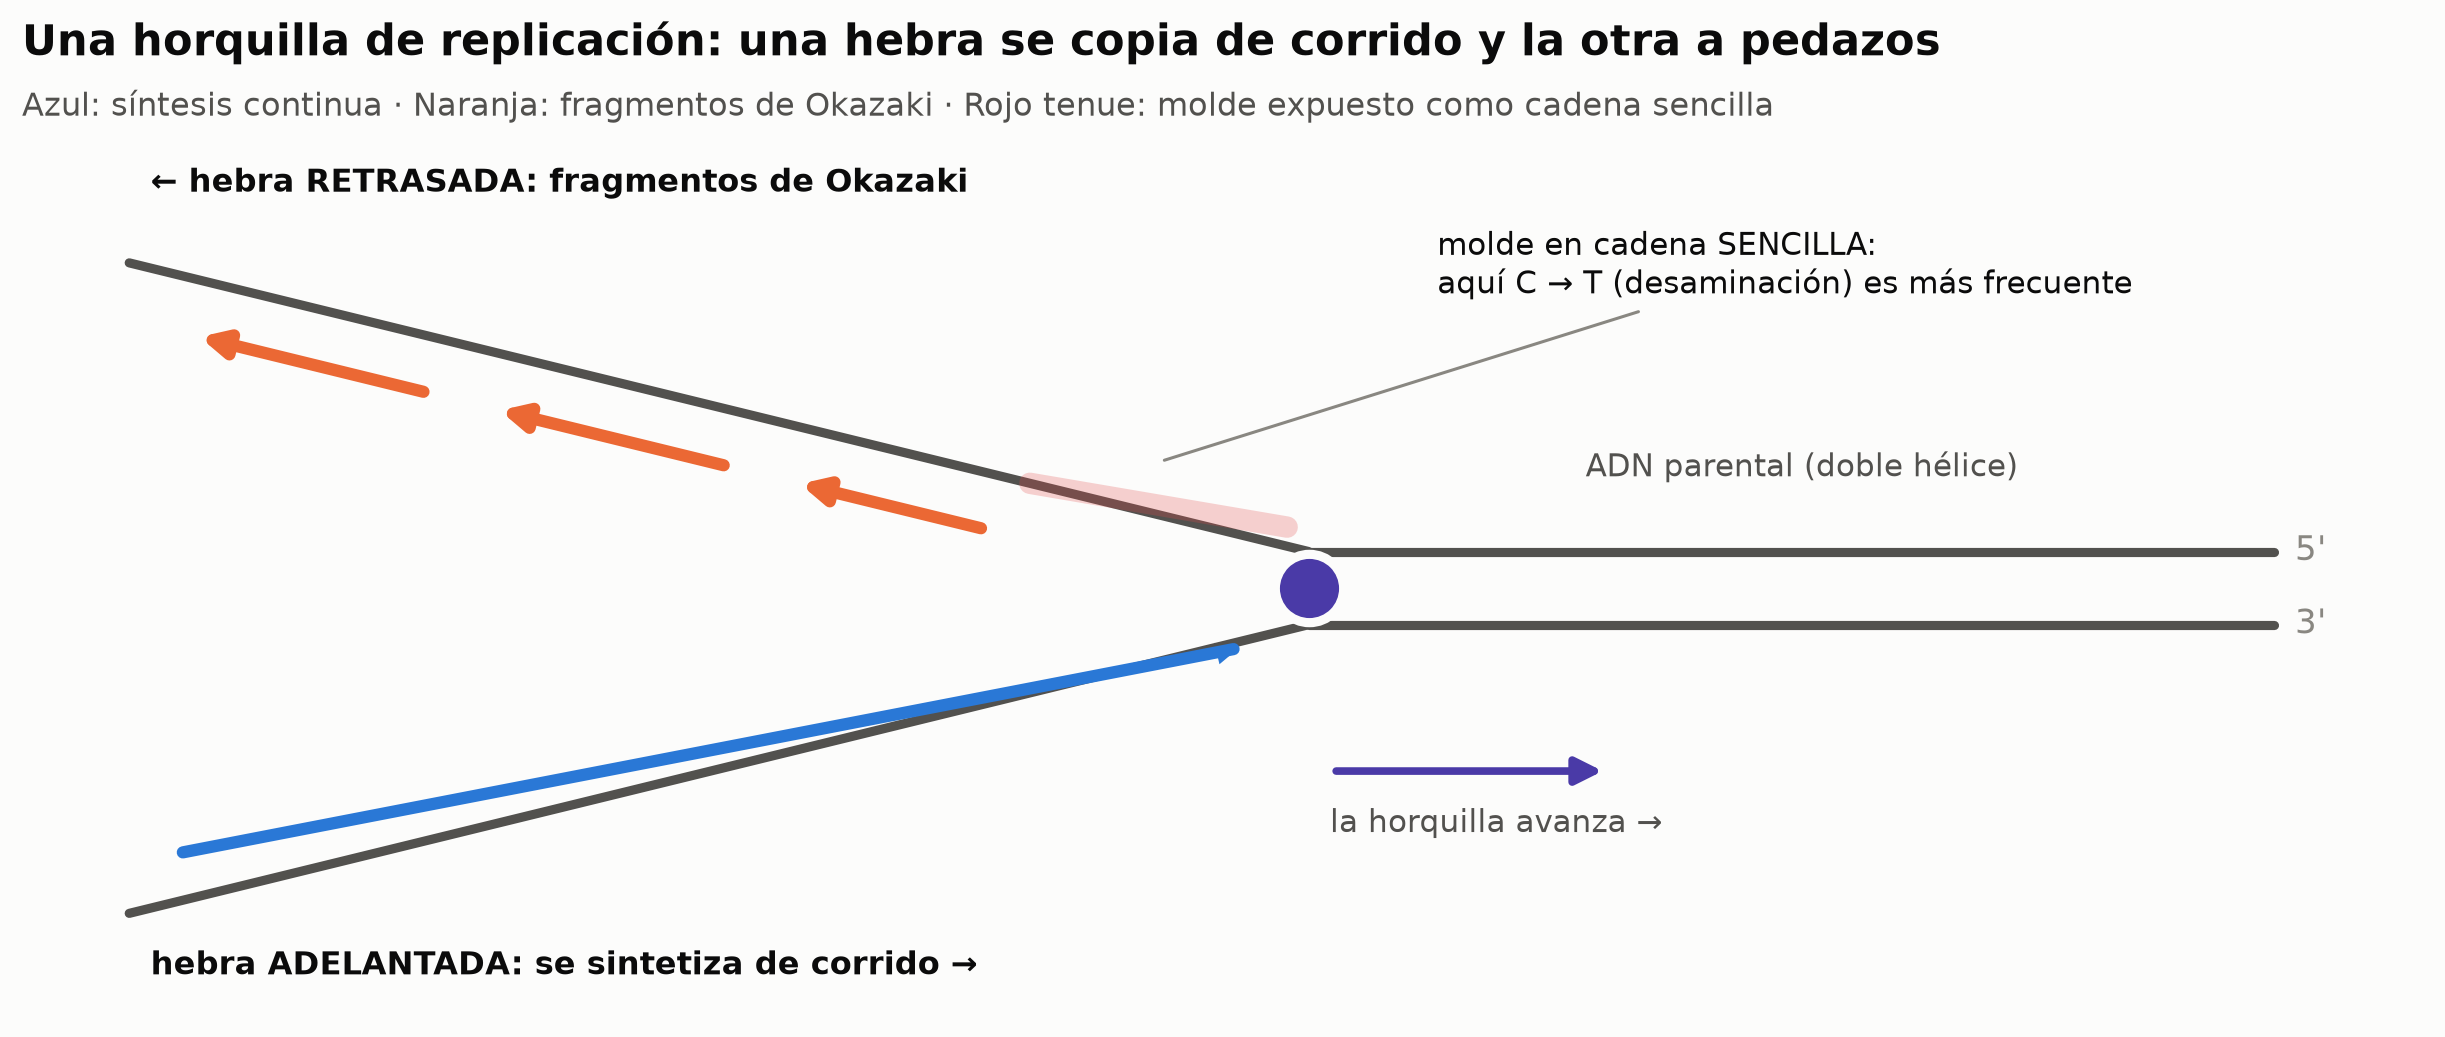

In [2]:
# Diagrama: una horquilla de replicación vista de cerca
from matplotlib.patches import FancyArrowPatch

fig, ax = plt.subplots(figsize=(11, 4.6))
ax.axis("off"); ax.grid(False)
fork_x = 6.0
# Doble hélice parental (a la derecha de la horquilla)
ax.plot([fork_x, 10.5], [0.18, 0.18], color=ec.INK_2, lw=3)
ax.plot([fork_x, 10.5], [-0.18, -0.18], color=ec.INK_2, lw=3)
ax.text(10.6, 0.18, "5'", va="center", color=ec.MUTED); ax.text(10.6, -0.18, "3'", va="center", color=ec.MUTED)
ax.text(8.3, 0.55, "ADN parental (doble hélice)", ha="center", color=ec.INK_2, fontsize=10)
# Hebras molde separadas (a la izquierda)
ax.plot([0.5, fork_x], [1.6, 0.18], color=ec.INK_2, lw=3)          # molde superior
ax.plot([0.5, fork_x], [-1.6, -0.18], color=ec.INK_2, lw=3)        # molde inferior
# Hebra adelantada: continua, pegada al molde inferior
ax.plot([0.75, fork_x - 0.35], [-1.3, -0.3], color=ec.BLUE, lw=4, solid_capstyle="round")
ax.add_patch(FancyArrowPatch((fork_x - 0.9, -0.44), (fork_x - 0.3, -0.29), arrowstyle="-|>", mutation_scale=18,
                             color=ec.BLUE, lw=0))
ax.text(0.6, -1.9, "hebra ADELANTADA: se sintetiza de corrido →", color=ec.INK, fontsize=10.5, fontweight="bold")
# Hebra retrasada: fragmentos de Okazaki
slope = (1.6 - 0.18) / (0.5 - fork_x)
for x0, x1 in [(0.8, 1.9), (2.2, 3.3), (3.6, 4.5)]:
    y0, y1 = 1.6 + slope * (x0 - 0.5) - 0.28, 1.6 + slope * (x1 - 0.5) - 0.28
    ax.annotate("", xy=(x0, y0), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color=ec.ORANGE, lw=4, mutation_scale=16))
ax.text(0.6, 1.95, "← hebra RETRASADA: fragmentos de Okazaki", color=ec.INK, fontsize=10.5, fontweight="bold")
# Zona de cadena sencilla expuesta
ax.plot([4.7, fork_x - 0.1], [1.6 + slope * (4.7 - 0.5), 0.3], color=ec.RED, lw=7, alpha=0.25,
        solid_capstyle="round")
ax.annotate("molde en cadena SENCILLA:\naquí C → T (desaminación) es más frecuente",
            xy=(5.3, 0.62), xytext=(6.6, 1.45), fontsize=10, color=ec.INK,
            arrowprops=dict(arrowstyle="-", color=ec.MUTED, lw=1))
# Horquilla y dirección
ax.scatter([fork_x], [0], s=500, color=ec.VIOLET, zorder=5, edgecolor=ec.SURFACE, linewidth=3)
ax.annotate("", xy=(fork_x + 1.4, -0.9), xytext=(fork_x + 0.1, -0.9),
            arrowprops=dict(arrowstyle="-|>", color=ec.VIOLET, lw=2.5, mutation_scale=18))
ax.text(fork_x + 0.1, -1.2, "la horquilla avanza →", color=ec.INK_2, fontsize=10)
ax.set_xlim(0, 11.2); ax.set_ylim(-2.1, 2.2)
ec.title(ax, "Una horquilla de replicación: una hebra se copia de corrido y la otra a pedazos",
         "Azul: síntesis continua · Naranja: fragmentos de Okazaki · Rojo tenue: molde expuesto como cadena sencilla")
plt.show()

### 🎬 Animación: dos horquillas recorren el cromosoma

En la animación el cromosoma circular empieza a copiarse en *oriC* (arriba). Las dos horquillas (puntos morados)
avanzan en sentidos opuestos hasta encontrarse en *ter* (abajo). En cada replicor se dibujan las dos hebras nuevas:
la **continua** (azul) y la hecha de **fragmentos de Okazaki** (naranja). Observe que **en el replicor derecho la
hebra continua está afuera y en el izquierdo está adentro**: los papeles de las dos hebras se **intercambian** al
cruzar *oriC* y *ter*.

🤔 **Antes de ver la animación, prediga:** si una hebra del ADN (digamos, la que leemos en el GenBank) es
"adelantada" en el replicor derecho, ¿qué papel cumple en el replicor izquierdo?

![Vista previa: replicación bidireccional desde oriC hasta ter (ejecute la celda de abajo para la versión con controles)](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-01-biologia-molecular/1.3_horquillas.gif)

*Vista previa: replicación bidireccional desde oriC hasta ter (ejecute la celda de abajo para la versión con controles)*

In [3]:
from matplotlib.patches import Arc

fig, ax = plt.subplots(figsize=(6.4, 6.4))
ax.set_aspect("equal"); ax.axis("off"); ax.grid(False)
ax.add_patch(plt.Circle((0, 0), 1.0, fill=False, color=ec.BASELINE, lw=5))
ax.text(0, 1.16, "oriC", ha="center", va="bottom", fontsize=12, fontweight="bold", color=ec.INK)
ax.text(0, -1.18, "ter", ha="center", va="top", fontsize=12, fontweight="bold", color=ec.INK)
ax.text(1.25, 0.0, "replicor\nderecho", ha="left", va="center", fontsize=10, color=ec.INK_2)
ax.text(-1.25, 0.0, "replicor\nizquierdo", ha="right", va="center", fontsize=10, color=ec.INK_2)
ax.set_xlim(-1.75, 1.75); ax.set_ylim(-1.55, 1.55)
title = ax.set_title("Replicación bidireccional", loc="left", fontsize=13)
clock = ax.text(-1.7, -1.5, "", fontsize=10, color=ec.INK_2)

n_frames = 44
artists = []
# ángulo matplotlib: 90° = arriba (oriC); el replicor derecho va de 90° hacia -90° (sentido horario)
def okazaki_arcs(r, theta_from, theta_to, color):
    """Arcos cortos (fragmentos de Okazaki) entre dos ángulos."""
    out = []
    lo, hi = sorted([theta_from, theta_to])
    for s in np.arange(lo, hi, 9):
        e = min(s + 6.5, hi)
        out.append(Arc((0, 0), 2 * r, 2 * r, theta1=s, theta2=e, color=color, lw=3.5))
    return out

def update(f):
    for a in artists:
        a.remove()
    artists.clear()
    progress = f / (n_frames - 1) * 180              # grados recorridos por cada horquilla
    if progress > 0:
        # replicor derecho: de 90 hacia 90-progress ; hebra continua afuera, Okazaki adentro
        artists.append(ax.add_patch(Arc((0, 0), 2.16, 2.16, theta1=90 - progress, theta2=90, color=ec.BLUE, lw=3.5)))
        artists.extend(ax.add_patch(a) for a in okazaki_arcs(0.92, 90 - progress, 90, ec.ORANGE))
        # replicor izquierdo: de 90 hacia 90+progress ; continua adentro, Okazaki afuera
        artists.append(ax.add_patch(Arc((0, 0), 1.84, 1.84, theta1=90, theta2=90 + progress, color=ec.BLUE, lw=3.5)))
        artists.extend(ax.add_patch(a) for a in okazaki_arcs(1.08, 90, 90 + progress, ec.ORANGE))
    for ang in (90 - progress, 90 + progress):
        x, y = np.cos(np.radians(ang)), np.sin(np.radians(ang))
        artists.append(ax.scatter([x], [y], s=160, color=ec.VIOLET, zorder=5, edgecolor=ec.SURFACE, linewidth=2))
    clock.set_text(f"tiempo ≈ {progress / 180 * 39:4.1f} min de ~39  ·  azul: continua · naranja: Okazaki")
    return artists

ec.animate(fig, update, frames=n_frames, interval=120, name="1.3_horquillas")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

🔎 **Qué observamos.** En el replicor derecho la hebra continua (azul) queda por fuera; en el izquierdo, por
dentro. Si fijamos **una** hebra del ADN (por ejemplo la hebra "de arriba", la que aparece escrita en el archivo
FASTA), esa hebra funciona como **molde de la hebra retrasada en un replicor y como molde de la adelantada en el
otro**. El cambio ocurre exactamente en *oriC* y en *ter*. Ese cambio de papel es lo que vamos a detectar en la
secuencia.

✅ **Compruebe su comprensión.** Si una bacteria tuviera **dos** orígenes de replicación en su cromosoma circular,
¿cuántas horquillas habría y cuántas veces cambiaría de papel una hebra dada?

## 2. La cicatriz de la replicación: de dónde sale el sesgo G/C

La citosina (C) tiene una debilidad química: puede perder un grupo amino y convertirse en uracilo, que la
maquinaria celular luego lee como timina. Es la **desaminación de la citosina**, y es la causa de muchas mutaciones
espontáneas **C → T**. Esta reacción es **unas cien veces más rápida en ADN de cadena sencilla** que en la doble
hélice, porque en la doble hélice la C está protegida por su pareja G, como un objeto frágil guardado dentro de
una caja con su tapa.

Ahora juntemos las piezas:

1. En cada replicor, la hebra que sirve de **molde para la hebra retrasada** pasa más tiempo como cadena sencilla.
2. Allí sus C mutan a T con más frecuencia.
3. Esa hebra **pierde C** poco a poco (y, por complementariedad, la hebra opuesta pierde G).
4. Tras millones de generaciones, **una hebra termina con más G que C en un replicor y con más C que G en el otro**.

Por convención, la hebra con el mismo sentido que la hebra adelantada acumula **más G que C** (y más T que A).
El resultado es una "firma" que cambia de signo exactamente en *oriC* y en *ter*.

> Este mecanismo (junto con otros, como la orientación preferente de los genes) fue propuesto por Lobry (1996) y
> Frank & Lobry (1999), y hoy es la base de programas que predicen orígenes de replicación.

## 3. 🧪 Simulación: ver nacer el sesgo en un genoma de juguete

Pongamos a prueba la explicación con un experimento computacional. Construimos un genoma circular de 100 kb **sin
ningún sesgo** (G y C igual de frecuentes en cada hebra), con *oriC* en la posición 0 y *ter* en 50 kb, y lo
dejamos evolucionar:

* En cada "época" aplicamos mutaciones al azar.
* En el replicor derecho (0–50 kb), las **C de la hebra de arriba** mutan a T con una tasa **extra** (esa hebra es
  el molde expuesto).
* En el replicor izquierdo (50–100 kb) ocurre lo mismo pero en la hebra de abajo; visto desde la hebra de arriba,
  eso son mutaciones **G → A**.
* Además hay mutaciones "normales", simétricas, que ocurren igual en todas partes.

🤔 **Antes de ejecutar, prediga:** ¿el sesgo $(G-C)/(G+C)$ de la hebra de arriba será positivo o negativo en el
replicor derecho? ¿Y en el izquierdo?

In [4]:
rng = np.random.default_rng(13)
L_toy = 100_000
ter_toy = L_toy // 2
BASES = np.array(list("ACGT"))
toy = rng.choice(BASES, L_toy)                              # genoma inicial, sin sesgo

def window_skew(seq_arr, window):
    """Sesgo (G-C)/(G+C) en ventanas contiguas de un arreglo de letras."""
    g = (seq_arr == "G").reshape(-1, window).sum(axis=1)
    c = (seq_arr == "C").reshape(-1, window).sum(axis=1)
    return (g - c) / np.maximum(g + c, 1)

def evolve(seq_arr, n_asym, n_sym, rng):
    """Una época de mutaciones: asimétricas por replicor + simétricas en todo el genoma."""
    s = seq_arr.copy()
    pos = rng.integers(0, L_toy, n_asym)
    right = pos < ter_toy
    # replicor derecho: C -> T en la hebra de arriba ; izquierdo: G -> A (C -> T en la hebra de abajo)
    rp = pos[right]; s[rp[s[rp] == "C"]] = "T"
    lp = pos[~right]; s[lp[s[lp] == "G"]] = "A"
    # mutaciones simétricas: cualquier base -> cualquier base (mantienen la composición global)
    sp = rng.integers(0, L_toy, n_sym)
    s[sp] = rng.choice(BASES, n_sym)
    return s

window_toy = 2_000
history = [window_skew(toy, window_toy)]
state = toy
for epoch in range(40):
    state = evolve(state, n_asym=1_500, n_sym=3_000, rng=rng)
    history.append(window_skew(state, window_toy))
history = np.array(history)
centers_toy = (np.arange(L_toy // window_toy) + 0.5) * window_toy
print("Sesgo medio replicor derecho, época 0 → 40:", round(history[0, :25].mean(), 3), "→", round(history[-1, :25].mean(), 3))
print("Sesgo medio replicor izquierdo, época 0 → 40:", round(history[0, 25:].mean(), 3), "→", round(history[-1, 25:].mean(), 3))

Sesgo medio replicor derecho, época 0 → 40: -0.005 → 0.157
Sesgo medio replicor izquierdo, época 0 → 40: 0.001 → -0.146


![Vista previa: el sesgo G/C aparece época tras época en el genoma de juguete](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-01-biologia-molecular/1.3_desaminacion.gif)

*Vista previa: el sesgo G/C aparece época tras época en el genoma de juguete*

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, height_ratios=[1.2, 1])
for ax in (ax1, ax2):
    ax.axvline(ter_toy, color=ec.BASELINE, lw=1)
ax1.axhline(0, color=ec.BASELINE, lw=1)
bars = ax1.bar(centers_toy, history[0], width=window_toy * 0.85, color=ec.BLUE)
ax1.set_ylim(-0.4, 0.4); ax1.set_ylabel("Sesgo por ventana")
ax1.text(ter_toy / 2, 0.33, "replicor derecho", ha="center", color=ec.INK_2)
ax1.text(ter_toy * 1.5, 0.33, "replicor izquierdo", ha="center", color=ec.INK_2)
cum_line, = ax2.plot([], [], color=ec.VIOLET, lw=2)
ax2.set_xlim(0, L_toy); ax2.set_ylim(-1, 14)
ax2.set_ylabel("Sesgo acumulado"); ax2.set_xlabel("Posición en el genoma de juguete")
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:.0f} kb"))
ax2.text(0, 13, "oriC", color=ec.INK, fontweight="bold"); ax2.text(ter_toy + 800, 13, "ter", color=ec.INK, fontweight="bold")
ttl = ax1.set_title("", loc="left")

def update(f):
    h = history[f]
    for b, v in zip(bars, h):
        b.set_height(v); b.set_color(ec.BLUE if v >= 0 else ec.RED)
    cum_line.set_data(centers_toy, np.cumsum(h))
    ttl.set_text(f"Época {f:2d}: el sesgo cambia de signo en ter")
    return list(bars) + [cum_line, ttl]

ec.animate(fig, update, frames=len(history), interval=150, name="1.3_desaminacion")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

🔎 **Qué observamos.** Al principio las barras oscilan al azar alrededor de cero. Época tras época, el replicor
derecho se vuelve **azul (G > C)** y el izquierdo **rojo (C > G)**. La curva acumulada (abajo) sube mientras
recorre el replicor derecho y baja en el izquierdo: su **máximo marca *ter*** y sus puntos más bajos marcan
***oriC*** (que, por ser el genoma circular, está a la vez en 0 y en 100 kb).

Nuestra simulación reproduce el patrón con un mecanismo muy simple. Esto no *prueba* que el mecanismo real sea
exactamente ése, pero demuestra que **una pequeña asimetría repetida durante mucho tiempo basta** para dejar una
huella medible en todo el genoma.

## 4. El sesgo GC: definición y cálculo a mano

Para medir la huella necesitamos un número. En una ventana de la secuencia contamos las G y las C y calculamos:

$$
\boxed{\;S \;=\; \frac{n_G - n_C}{n_G + n_C}\;}
\qquad\qquad -1 \le S \le 1
$$

| Símbolo | Significado |
|---|---|
| $n_G$ | número de guaninas en la ventana (en la hebra que estamos leyendo) |
| $n_C$ | número de citosinas en la misma ventana y la misma hebra |
| $n_G - n_C$ | el **exceso** de G sobre C (puede ser negativo) |
| $n_G + n_C$ | normaliza: convierte el exceso en una **proporción** |
| $S$ | sesgo GC: $+1$ sólo G, $-1$ sólo C, $0$ equilibrio |

**Ejemplo a mano.** Tome la ventana `GGCAGCTGGA`:

* G en las posiciones 1, 2, 5, 8, 9 → $n_G = 5$
* C en las posiciones 3, 6 → $n_C = 2$
* $S = \dfrac{5-2}{5+2} = \dfrac{3}{7} \approx 0.43$

Observe que **en la hebra complementaria el signo se invierte**: cada G de una hebra es una C de la otra. Por eso el
sesgo sólo tiene sentido si siempre leemos **la misma hebra**, la que viene en el archivo.

### El sesgo acumulado: un saldo bancario

Las ventanas individuales son ruidosas. Una idea muy poderosa es **sumar** a medida que avanzamos por el genoma,
como el saldo de una cuenta bancaria: cada G es un depósito de +1 y cada C un retiro de −1.

$$
\mathrm{CS}(k) \;=\; \sum_{i=1}^{k} \big(\,\mathbb{1}[x_i = \mathrm{G}] \;-\; \mathbb{1}[x_i = \mathrm{C}]\,\big)
$$

| Símbolo | Significado |
|---|---|
| $x_i$ | la base en la posición $i$ |
| $\mathbb{1}[\cdot]$ | función indicadora: vale 1 si la condición se cumple y 0 si no |
| $\mathrm{CS}(k)$ | sesgo acumulado desde el inicio hasta la posición $k$ |

Mientras recorremos un tramo con más G que C, el saldo sube; con más C que G, baja. **El mínimo del saldo** está
donde se pasa de "gastar" a "ahorrar": ahí cambia el signo del sesgo, es decir, en ***oriC***. **El máximo** marca
***ter***. Con el saldo el ruido de cada ventana se promedia y el patrón global salta a la vista.

In [6]:
def gc_skew(seq: str) -> float:
    g, c = seq.count("G"), seq.count("C")
    return (g - c) / (g + c) if (g + c) else 0.0

print("Ventana GGCAGCTGGA → S =", round(gc_skew("GGCAGCTGGA"), 3), "(a mano: 3/7 = 0.429)")

def cumulative_skew(seq: str) -> np.ndarray:
    """Saldo acumulado: +1 por cada G, −1 por cada C, 0 por A o T."""
    arr = np.frombuffer(seq.encode("ascii"), dtype=np.uint8)
    step = (arr == ord("G")).astype(np.int32) - (arr == ord("C")).astype(np.int32)
    return np.cumsum(step)

print("Saldo acumulado de GGCAGCTGGA:", cumulative_skew("GGCAGCTGGA"))

Ventana GGCAGCTGGA → S = 0.429 (a mano: 3/7 = 0.429)
Saldo acumulado de GGCAGCTGGA: [1 2 1 1 2 1 1 2 3 3]


## 5. 🧪 Experimento: encontrar *oriC* en el genoma de *Escherichia coli*

Ahora la prueba de fuego con datos reales: el genoma de referencia de *E. coli* K-12 MG1655 (`NC_000913.3`,
4 641 652 pb). Lo descargamos del NCBI en formato FASTA (≈ 4.7 MB). Si la descarga falla, la celda usa una copia
comprimida guardada en el repositorio del curso.

In [7]:
ACC = "NC_000913.3"

def load_fasta_record(acc):
    local = f"../data/{acc}.fasta.gz"                 # copia del repositorio (si el notebook corre dentro de él)
    if os.path.exists(local):
        with gzip.open(local, "rt") as fh:
            print("Usando la copia local del repositorio")
            return SeqIO.read(fh, "fasta")
    try:
        with Entrez.efetch(db="nuccore", id=acc, rettype="fasta", retmode="text") as handle:
            rec = SeqIO.read(handle, "fasta")
        print("Descargado del NCBI ✔")
        return rec
    except Exception as err:
        print("NCBI no respondió (", err, ") → usando la copia del curso")
        data = urllib.request.urlopen(f"{RAW}/data/{acc}.fasta.gz").read()
        return SeqIO.read(io.StringIO(gzip.decompress(data).decode()), "fasta")

ecoli = load_fasta_record(ACC)
ecoli_seq = str(ecoli.seq).upper()
L = len(ecoli_seq)
print(ecoli.description)
print(f"Longitud: {L:,} pb")

Usando la copia local del repositorio
NC_000913.3 Escherichia coli str. K-12 substr. MG1655, complete genome
Longitud: 4,641,652 pb


Según la anotación del propio GenBank de `NC_000913.3`, el origen de replicación (*feature* `rep_origin`, nota
`oriC`) ocupa las posiciones **3 925 744–3 925 975**. No hay una anotación de *ter* como tal, pero sí del gen
**`tus`** (1 684 259–1 685 188), que codifica la proteína que se une a los sitios de terminación y detiene las
horquillas: es un buen marcador de la región *ter*. En el Ejercicio 3 usted verificará estas coordenadas.

🤔 **Antes de ejecutar, prediga:** ¿dónde debería estar el mínimo del sesgo acumulado? ¿Y el máximo? ¿A qué
distancia (en kb) de *oriC* esperaría encontrar la región *ter* si las dos horquillas avanzan a la misma velocidad?

In [8]:
ORI_ANNOT = (3_925_744, 3_925_975)          # rep_origin "oriC" en el GenBank NC_000913.3
TUS_ANNOT = (1_684_259, 1_685_188)          # gen tus (región de terminación)

cs = cumulative_skew(ecoli_seq)
pred_ori = int(np.argmin(cs)) + 1            # +1: coordenadas biológicas (1-based)
pred_ter = int(np.argmax(cs)) + 1
ori_mid = np.mean(ORI_ANNOT)

def circ_dist(a, b, L=L):
    d = abs(a - b) % L
    return min(d, L - d)

print(f"Mínimo del sesgo acumulado (predicción de oriC): {pred_ori:,}")
print(f"oriC anotado:                                    {ORI_ANNOT[0]:,}–{ORI_ANNOT[1]:,}")
print(f"  → diferencia: {circ_dist(pred_ori, ori_mid)/1000:.1f} kb  ({circ_dist(pred_ori, ori_mid)/L:.2%} del genoma)")
print(f"Máximo del sesgo acumulado (predicción de ter):  {pred_ter:,}")
print(f"  → distancia al gen tus: {circ_dist(pred_ter, np.mean(TUS_ANNOT))/1000:.0f} kb")
print(f"  → distancia oriC–ter por un lado: {((pred_ori - pred_ter) % L)/1e6:.2f} Mb; por el otro: {((pred_ter - pred_ori) % L)/1e6:.2f} Mb")

Mínimo del sesgo acumulado (predicción de oriC): 3,925,597
oriC anotado:                                    3,925,744–3,925,975
  → diferencia: 0.3 kb  (0.01% del genoma)
Máximo del sesgo acumulado (predicción de ter):  1,552,389
  → distancia al gen tus: 132 kb
  → distancia oriC–ter por un lado: 2.37 Mb; por el otro: 2.27 Mb


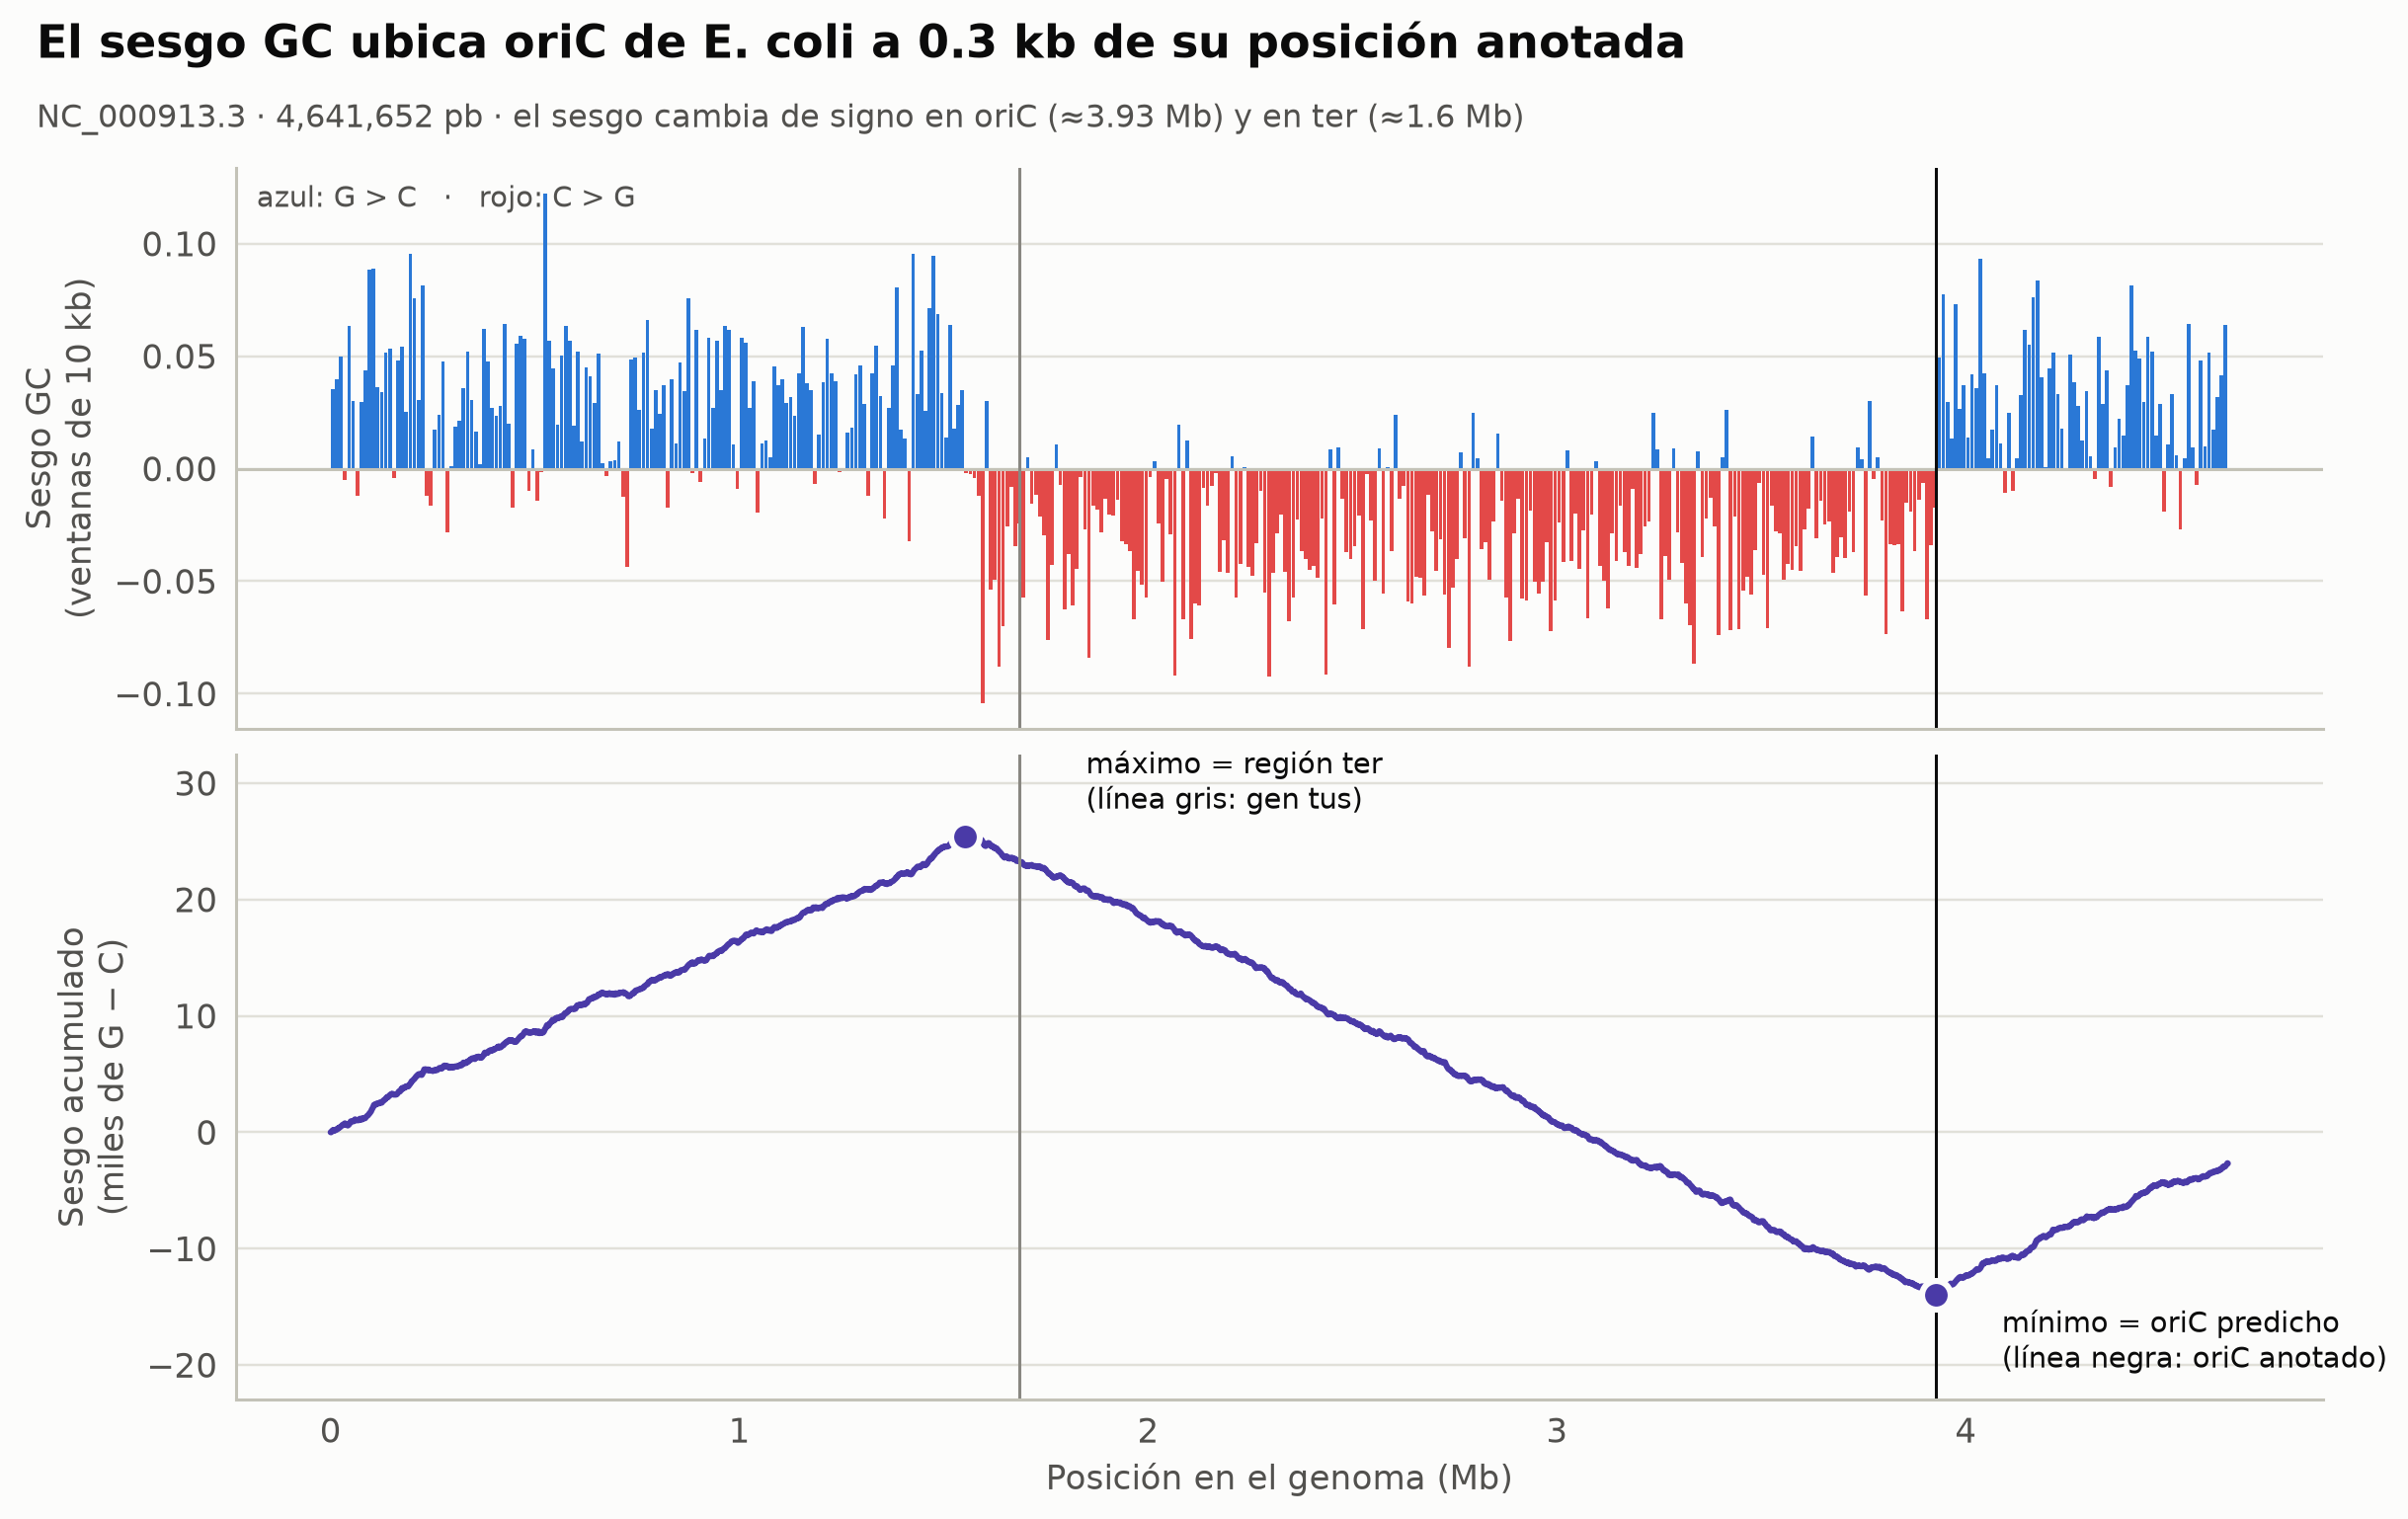

In [9]:
window = 10_000
n_win = L // window
arr = np.frombuffer(ecoli_seq[: n_win * window].encode("ascii"), dtype=np.uint8).reshape(n_win, window)
g_w = (arr == ord("G")).sum(axis=1); c_w = (arr == ord("C")).sum(axis=1)
skew_w = (g_w - c_w) / (g_w + c_w)
centers = (np.arange(n_win) + 0.5) * window

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6.2), sharex=True, height_ratios=[1, 1.15])
colors = np.where(skew_w >= 0, ec.BLUE, ec.RED)
ax1.bar(centers / 1e6, skew_w, width=window / 1e6 * 0.9, color=colors)
ax1.axhline(0, color=ec.BASELINE, lw=1)
ax1.set_ylabel("Sesgo GC\n(ventanas de 10 kb)")

step = 1_000
ax2.plot(np.arange(0, L, step) / 1e6, cs[::step] / 1000, color=ec.VIOLET, lw=2)
ax2.set_ylabel("Sesgo acumulado\n(miles de G − C)")
ax2.set_ylim(cs.min() / 1000 - 9, cs.max() / 1000 + 7)
ax2.set_xlabel("Posición en el genoma (Mb)")
for ax in (ax1, ax2):
    ax.axvline(ori_mid / 1e6, color=ec.INK, lw=1, ls="-")
    ax.axvline(np.mean(TUS_ANNOT) / 1e6, color=ec.MUTED, lw=1)
ax2.scatter([pred_ori / 1e6], [cs[pred_ori - 1] / 1000], s=90, color=ec.VIOLET, edgecolor=ec.SURFACE, linewidth=2, zorder=4)
ax2.scatter([pred_ter / 1e6], [cs[pred_ter - 1] / 1000], s=90, color=ec.VIOLET, edgecolor=ec.SURFACE, linewidth=2, zorder=4)
ax2.annotate("mínimo = oriC predicho\n(línea negra: oriC anotado)", xy=(pred_ori / 1e6, cs[pred_ori - 1] / 1000),
             xytext=(22, -4), textcoords="offset points", ha="left", va="top", fontsize=9.5, color=ec.INK,
             arrowprops=dict(arrowstyle="-", color=ec.MUTED))
ax2.annotate("máximo = región ter\n(línea gris: gen tus)", xy=(pred_ter / 1e6, cs[pred_ter - 1] / 1000),
             xytext=(40, 6), textcoords="offset points", ha="left", va="bottom", fontsize=9.5, color=ec.INK,
             arrowprops=dict(arrowstyle="-", color=ec.MUTED))
ax1.text(0.01, 0.97, "azul: G > C   ·   rojo: C > G", transform=ax1.transAxes, ha="left", va="top",
         fontsize=9.5, color=ec.INK_2)
ec.fig_title(fig, f"El sesgo GC ubica oriC de E. coli a {circ_dist(pred_ori, ori_mid)/1000:.1f} kb de su posición anotada",
             f"{ACC} · {L:,} pb · el sesgo cambia de signo en oriC (≈3.93 Mb) y en ter (≈1.6 Mb)")
plt.show()

🔎 **Qué observamos.** El genoma se divide limpiamente en dos mitades de signo opuesto. El sesgo acumulado tiene
forma de "V" invertida con el mínimo prácticamente encima del *oriC* anotado y el máximo cerca del gen `tus`, en el
lado opuesto del círculo. Con **un cálculo de una línea sobre la secuencia**, sin pipetas ni geles, hemos ubicado
el origen de replicación con un error de unas pocas kilobases en un genoma de 4.6 millones.

Note también que el sesgo por ventana es pequeño (de unos pocos puntos porcentuales) y ruidoso: por eso el saldo
acumulado es mucho más útil que las ventanas sueltas.

### 🖱️ Gráfico interactivo: explore el sesgo acumulado

Pase el cursor por la curva para ver la posición exacta y el saldo; haga zoom arrastrando un rectángulo (doble clic
para volver). Acérquese a la región de *oriC*: ¿qué tan "puntiagudo" es el mínimo?

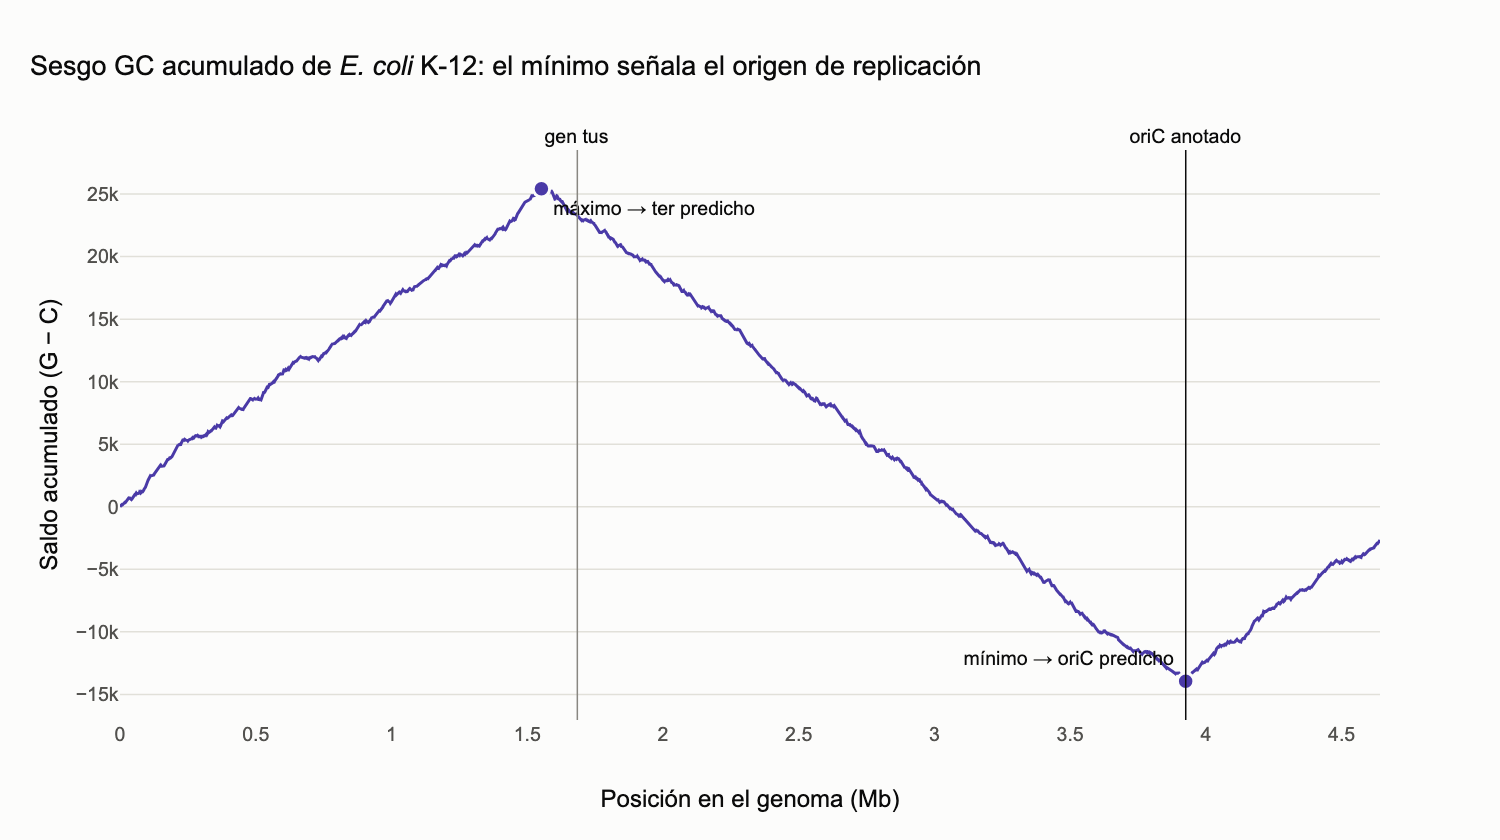

In [10]:
step_i = 500
x_mb = np.arange(0, L, step_i) / 1e6
fig_i = go.Figure()
fig_i.add_trace(go.Scatter(
    x=x_mb, y=cs[::step_i], mode="lines", line=dict(color=ec.VIOLET, width=2), name="sesgo acumulado",
    hovertemplate="Posición: %{x:.3f} Mb<br>Saldo G−C acumulado: %{y:,}<extra></extra>"))
fig_i.add_trace(go.Scatter(
    x=[pred_ori / 1e6, pred_ter / 1e6], y=[cs[pred_ori - 1], cs[pred_ter - 1]], mode="markers+text",
    marker=dict(size=11, color=ec.VIOLET, line=dict(color=ec.SURFACE, width=2)),
    text=["mínimo → oriC predicho", "máximo → ter predicho"], textposition=["top left", "bottom right"],
    name="predicciones", hovertemplate="%{text}<br>%{x:.3f} Mb<extra></extra>"))
fig_i.add_vline(x=ori_mid / 1e6, line=dict(color=ec.INK, width=1),
                annotation_text="oriC anotado", annotation_position="top")
fig_i.add_vline(x=np.mean(TUS_ANNOT) / 1e6, line=dict(color=ec.MUTED, width=1),
                annotation_text="gen tus", annotation_position="top")
fig_i.update_layout(
    title=dict(text="Sesgo GC acumulado de <i>E. coli</i> K-12: el mínimo señala el origen de replicación"),
    xaxis_title="Posición en el genoma (Mb)", yaxis_title="Saldo acumulado (G − C)",
    height=480, showlegend=False, hovermode="x unified")
fig_i.show()

## 6. El genoma como un reloj: mapa circular

Como el cromosoma es circular, la forma más natural de verlo es como la esfera de un reloj: la posición 0 arriba,
avanzando en el sentido de las manecillas. En este mapa:

* el **anillo externo** muestra cuánto se aleja el contenido GC de cada ventana del promedio del genoma;
* el **anillo interno** muestra el sesgo GC (azul positivo, rojo negativo).

Los genomas bacterianos casi siempre se publican con un mapa así.

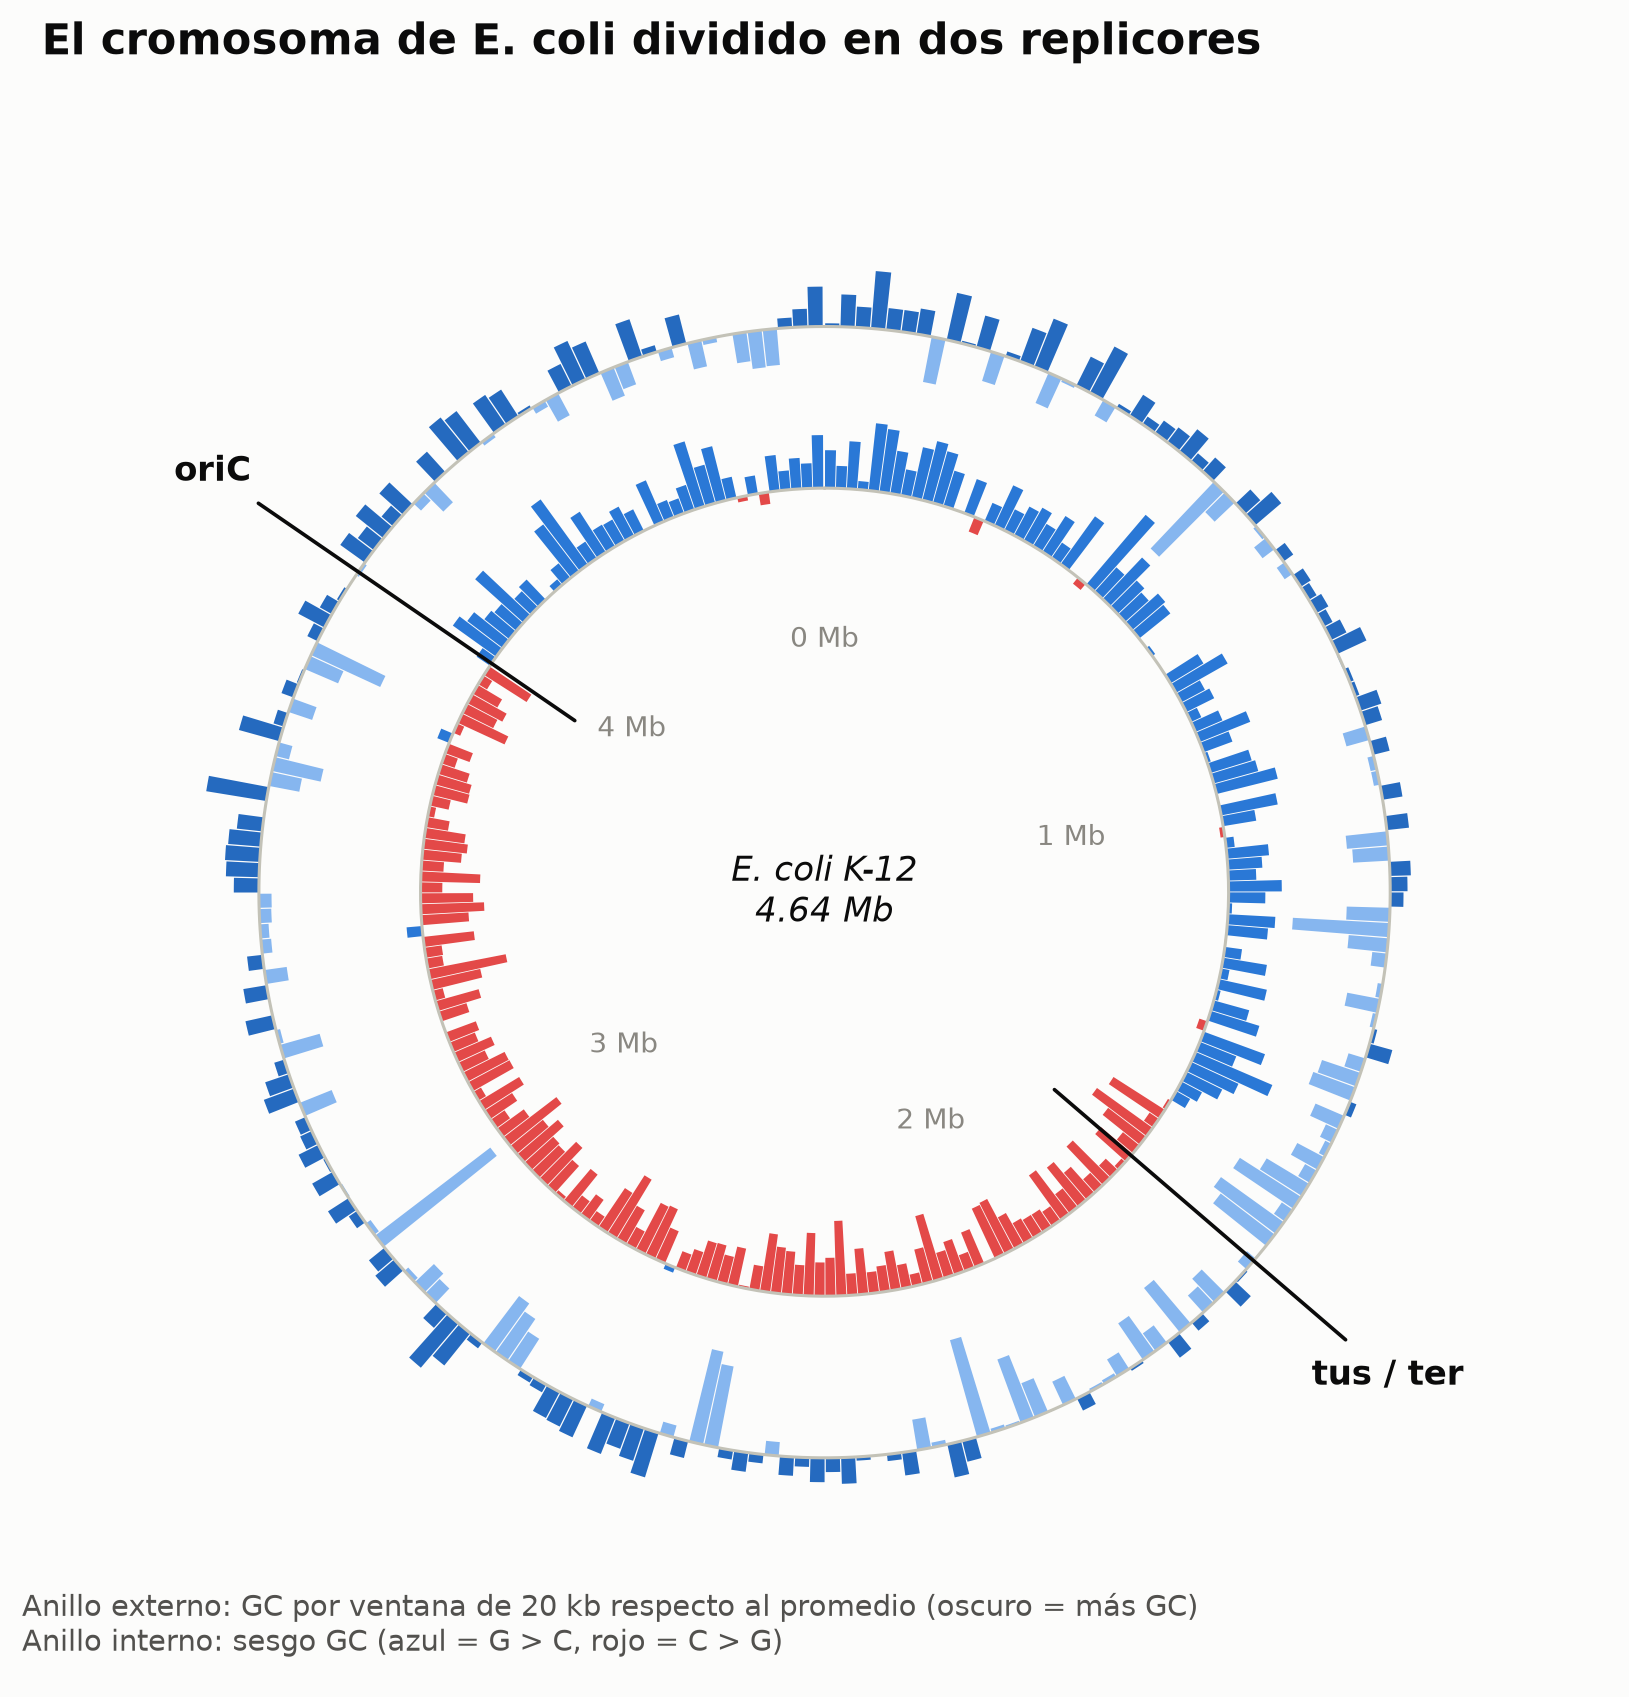

In [11]:
win_c = 20_000
n_c = L // win_c
arr_c = np.frombuffer(ecoli_seq[: n_c * win_c].encode("ascii"), dtype=np.uint8).reshape(n_c, win_c)
g_c = (arr_c == ord("G")).sum(1); c_c = (arr_c == ord("C")).sum(1)
gc_c = (g_c + c_c) / win_c
skew_c = (g_c - c_c) / (g_c + c_c)
theta = 2 * np.pi * (np.arange(n_c) + 0.5) * win_c / L
width = 2 * np.pi * win_c / L * 0.92

fig = plt.figure(figsize=(7.6, 7.6))
ax = fig.add_subplot(projection="polar")
ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
ax.grid(False); ax.set_yticks([]); ax.set_xticks([]); ax.spines["polar"].set_visible(False)
# anillo externo: desviación del GC respecto al promedio
dev = gc_c - gc_c.mean()
ax.plot(t := np.linspace(0, 2 * np.pi, 400), np.full(400, 1.12), color=ec.BASELINE, lw=1)
ax.bar(theta, dev * 3, width=width, bottom=1.12, color=np.where(dev >= 0, ec.SEQ_BLUE[8], ec.SEQ_BLUE[3]))
# círculo base del genoma
ax.plot(t, np.full_like(t, 0.8), color=ec.BASELINE, lw=1)
# anillo interno: sesgo GC
ax.bar(theta, skew_c * 2, width=width, bottom=0.8, color=np.where(skew_c >= 0, ec.BLUE, ec.RED))
# marcas de oriC y ter
for pos, lab in [(ori_mid, "oriC"), (np.mean(TUS_ANNOT), "tus / ter")]:
    th = 2 * np.pi * pos / L
    ax.plot([th, th], [0.6, 1.36], color=ec.INK, lw=1.2)
    ax.text(th, 1.47, lab, ha="center", va="center", fontsize=11, fontweight="bold", color=ec.INK)
for mb in range(0, 5):
    th = 2 * np.pi * mb * 1e6 / L
    ax.text(th, 0.5, f"{mb} Mb", ha="center", va="center", fontsize=9, color=ec.MUTED)
ax.set_ylim(0, 1.55)
ax.text(0, 0, f"E. coli K-12\n{L/1e6:.2f} Mb", ha="center", va="center", fontsize=11, color=ec.INK, style="italic")
ax.set_title("El cromosoma de E. coli dividido en dos replicores", loc="left", pad=18)
fig.text(0.02, 0.02, "Anillo externo: GC por ventana de 20 kb respecto al promedio (oscuro = más GC)\n"
         "Anillo interno: sesgo GC (azul = G > C, rojo = C > G)", fontsize=9.5, color=ec.INK_2)
plt.show()

🔎 **Qué observamos.** El anillo interno es azul en una mitad del reloj y rojo en la otra, con las fronteras en
*oriC* y en la región de *tus*. El contenido GC (anillo externo), en cambio, **no** muestra ese patrón: el sesgo GC
es una propiedad de **las hebras**, no de la cantidad total de G + C.

✅ **Compruebe su comprensión.** Si alguien le entrega el genoma escrito en la hebra complementaria (el complemento
reverso), ¿cómo se vería el anillo interno? ¿Seguiría encontrando *oriC* en el mismo lugar?

## 7. ¿Qué tan grande debe ser la ventana? Señal contra ruido

Ya conoce este problema desde la Lección 0.1: una ventana pequeña da mucho detalle pero mucho ruido. Hagamos el
cálculo para el sesgo.

Suponga que en una ventana hay $m$ bases que son G o C, y que **no hay ningún sesgo real**: cada una tiene
probabilidad $1/2$ de ser G. Entonces el número de G sigue una binomial, $K \sim \mathrm{Bin}(m, 1/2)$, y el sesgo
es $S = \frac{K - (m-K)}{m} = \frac{2K - m}{m}$. Su dispersión puramente aleatoria es:

$$
\mathrm{SD}(S) \;=\; \frac{2}{m}\,\mathrm{SD}(K) \;=\; \frac{2}{m}\sqrt{m \cdot \tfrac12 \cdot \tfrac12}
\;=\; \boxed{\;\frac{1}{\sqrt{m}}\;}
$$

| Símbolo | Significado |
|---|---|
| $m$ | número de G + C en la ventana ($\approx$ tamaño de ventana × contenido GC) |
| $K$ | número de G entre esas $m$ bases |
| $\mathrm{SD}(S)$ | el "ruido de fondo" del sesgo: lo que variaría aunque no hubiera ninguna señal biológica |

**Ejemplo a mano.** Con ventanas de 1 kb y GC ≈ 51 %, $m \approx 510$ y el ruido es $1/\sqrt{510} \approx 0.044$.
Si la señal real es de unos pocos puntos porcentuales ($\approx 0.02$–$0.03$), **el ruido es mayor que la señal**:
con ventanas de 1 kb no veríamos nada claro. Con 100 kb, $m \approx 51\,000$ y el ruido baja a $\approx 0.004$.

🤔 **Antes de ejecutar, prediga:** ¿con qué tamaño de ventana empieza a verse claramente la división en dos
mitades?

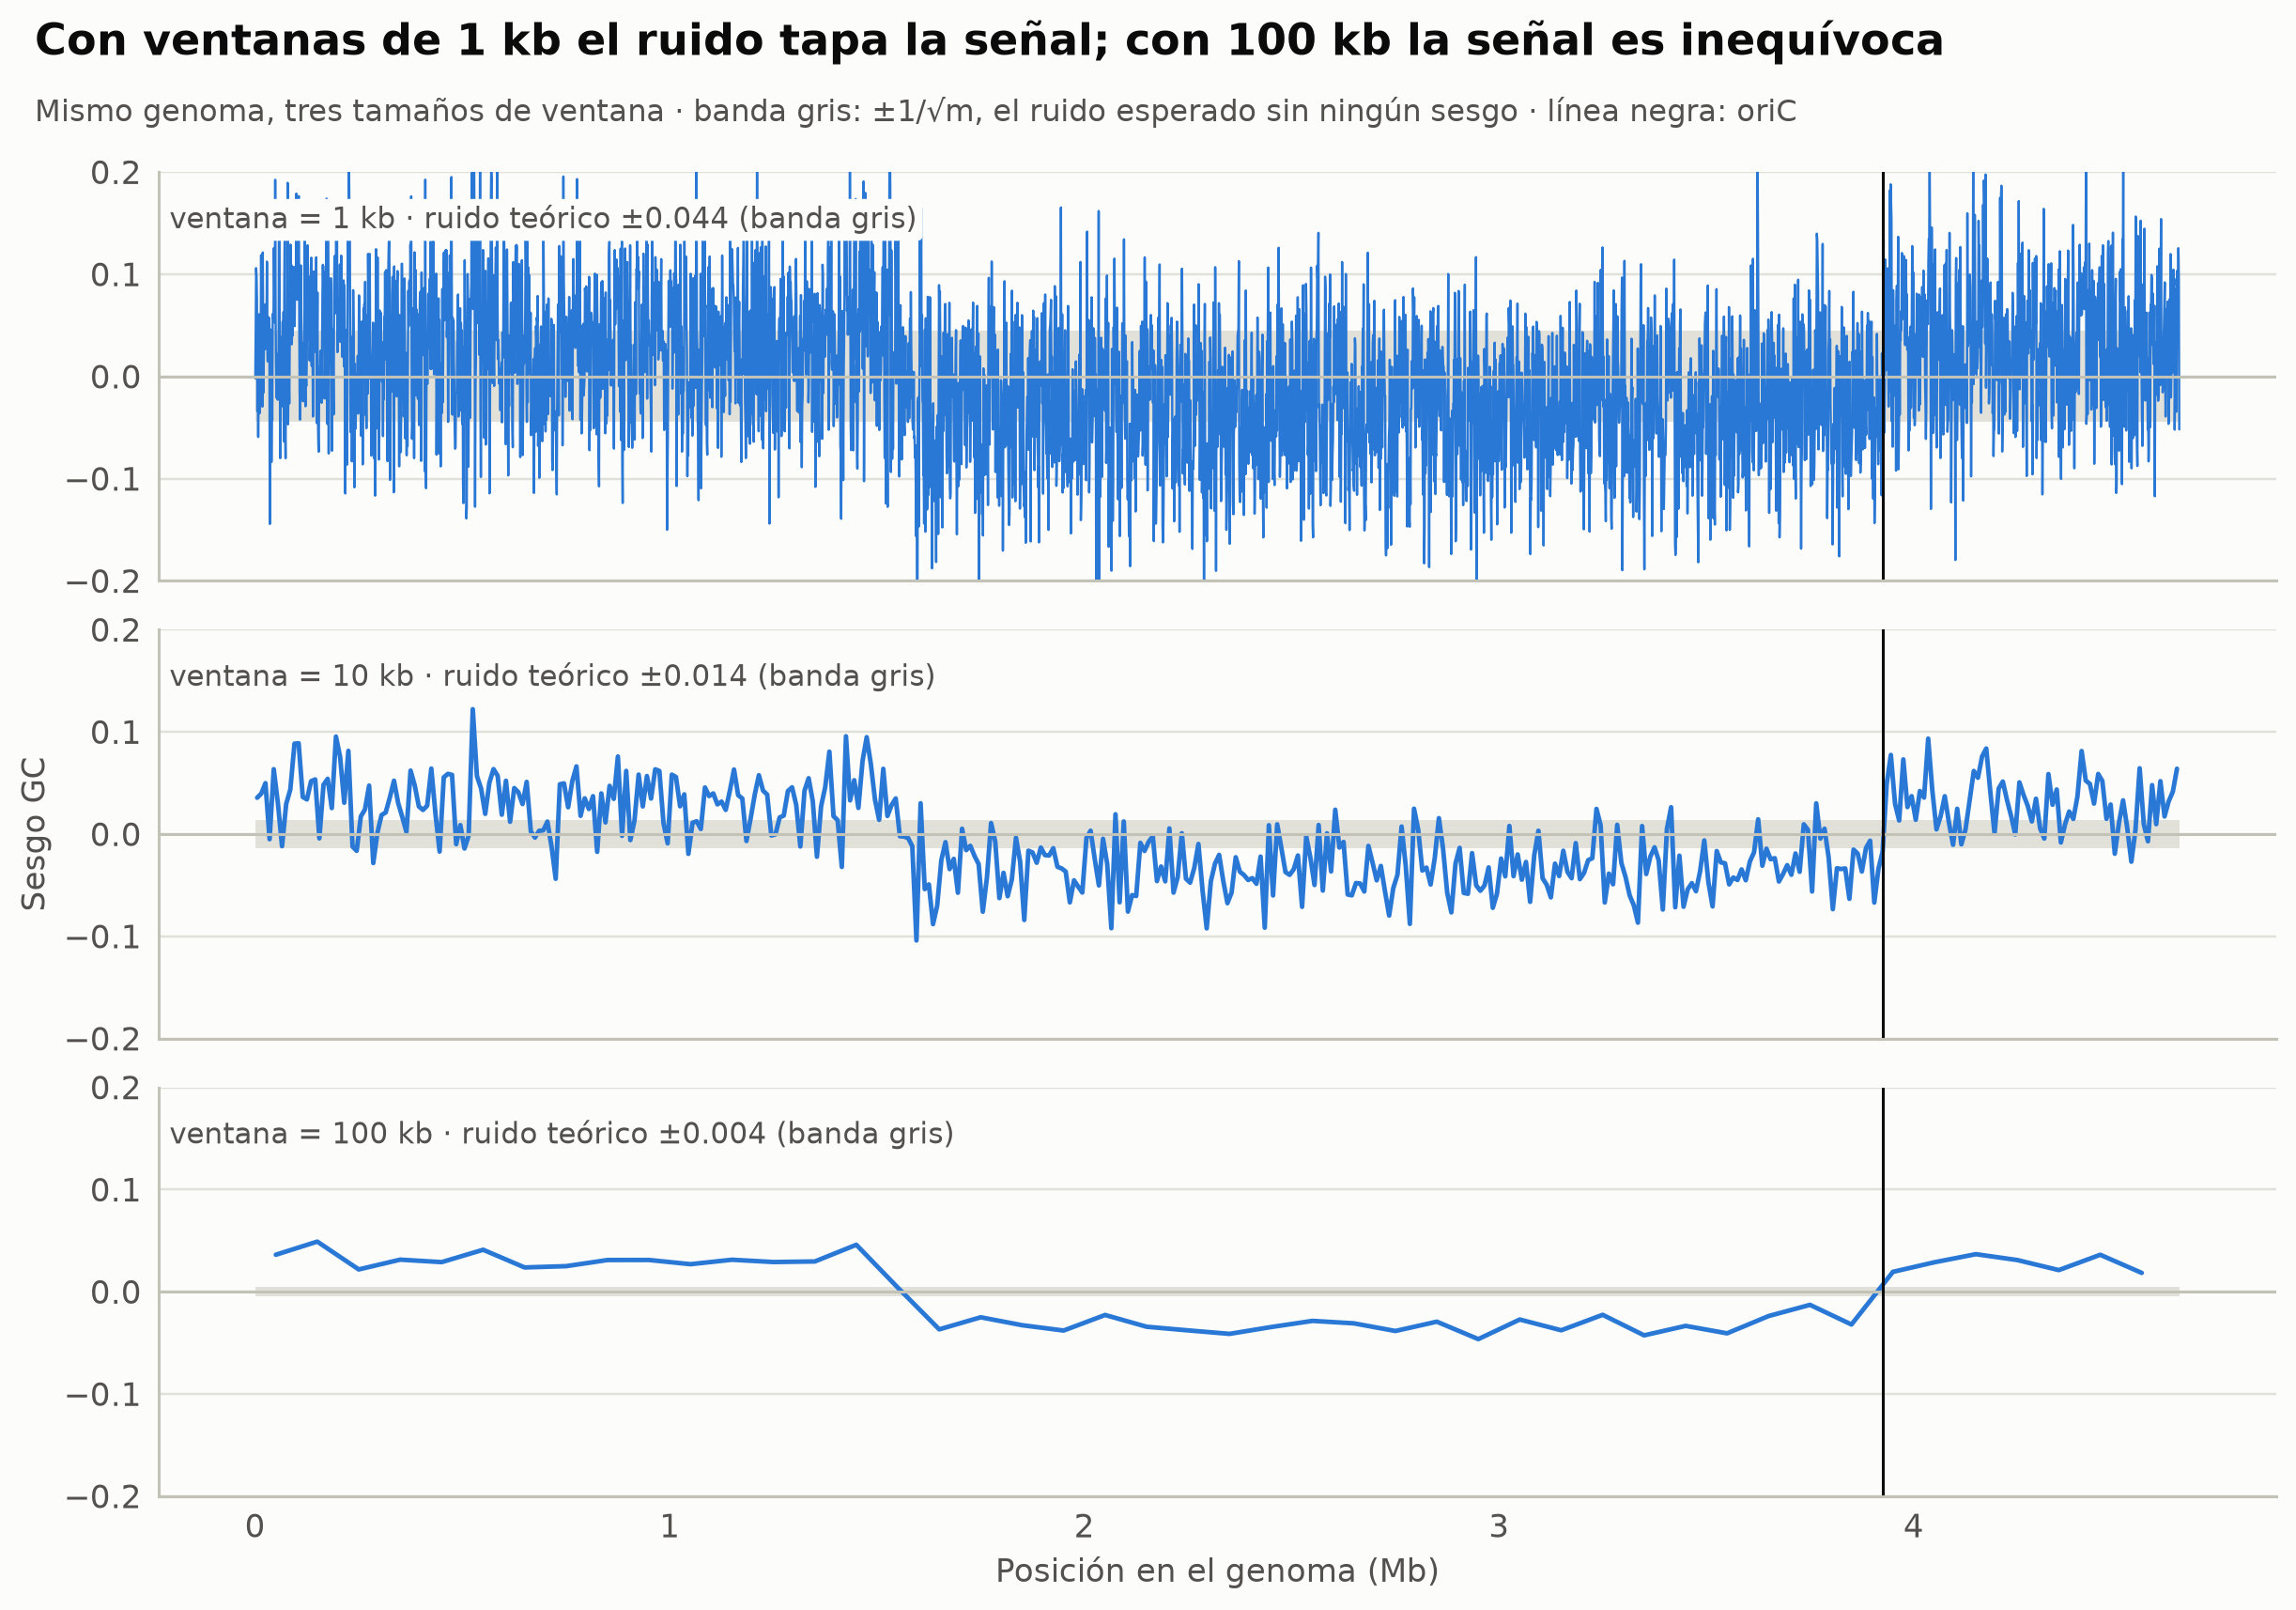

In [12]:
gc_global = (ecoli_seq.count("G") + ecoli_seq.count("C")) / L
sizes = [1_000, 10_000, 100_000]
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True, sharey=True)
for ax, w in zip(axes, sizes):
    n = L // w
    a = np.frombuffer(ecoli_seq[: n * w].encode("ascii"), dtype=np.uint8).reshape(n, w)
    g = (a == ord("G")).sum(1); c = (a == ord("C")).sum(1)
    s = (g - c) / (g + c)
    x = (np.arange(n) + 0.5) * w / 1e6
    noise = 1 / np.sqrt(w * gc_global)
    ax.fill_between([0, L / 1e6], -noise, noise, color=ec.GRID, lw=0)
    ax.plot(x, s, color=ec.BLUE, lw=0.8 if w == 1_000 else 1.6)
    ax.axhline(0, color=ec.BASELINE, lw=1)
    ax.axvline(ori_mid / 1e6, color=ec.INK, lw=1)
    ax.text(0.005, 0.92, f"ventana = {w/1000:.0f} kb · ruido teórico ±{noise:.3f} (banda gris)",
            transform=ax.transAxes, va="top", fontsize=10, color=ec.INK_2,
            bbox=dict(boxstyle="round,pad=0.2", fc=ec.SURFACE, ec="none"))
axes[0].set_ylim(-0.2, 0.2)
axes[-1].set_xlabel("Posición en el genoma (Mb)")
axes[1].set_ylabel("Sesgo GC")
ec.fig_title(fig, "Con ventanas de 1 kb el ruido tapa la señal; con 100 kb la señal es inequívoca",
             "Mismo genoma, tres tamaños de ventana · banda gris: ±1/√m, el ruido esperado sin ningún sesgo · línea negra: oriC")
plt.show()

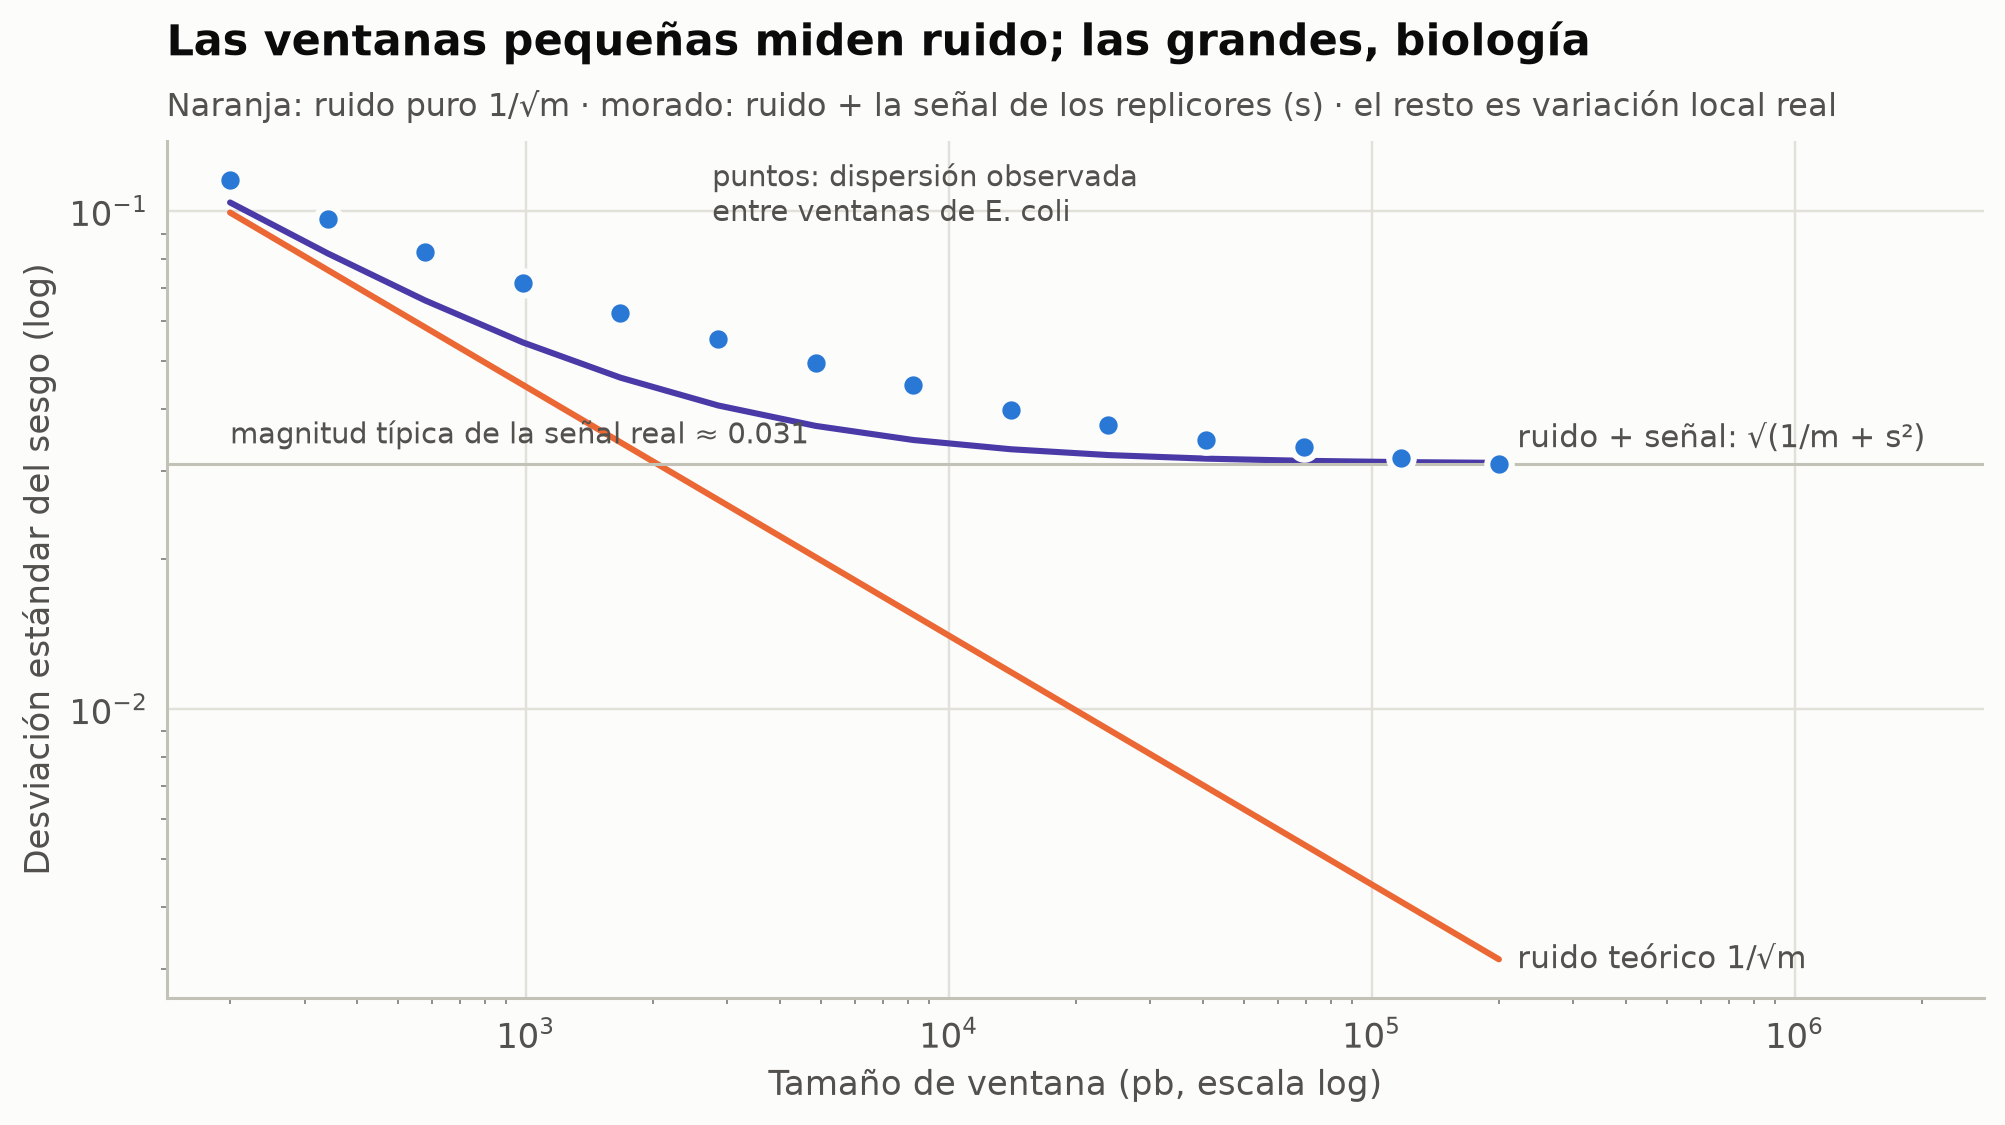

In [13]:
# Cuantifiquemos: dispersión observada del sesgo por ventana vs. el ruido teórico 1/√m
sizes_all = np.unique(np.logspace(np.log10(200), np.log10(200_000), 14).astype(int))
obs_sd, signal = [], []
for w in sizes_all:
    n = L // w
    a = np.frombuffer(ecoli_seq[: n * w].encode("ascii"), dtype=np.uint8).reshape(n, w)
    g = (a == ord("G")).sum(1); c = (a == ord("C")).sum(1)
    s = (g - c) / (g + c)
    obs_sd.append(s.std()); signal.append(np.abs(s).mean())
theory = 1 / np.sqrt(sizes_all * gc_global)
mean_abs_100k = signal[-2]

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(sizes_all, theory, color=ec.ORANGE, lw=2)
combined = np.sqrt(theory**2 + mean_abs_100k**2)            # ruido + señal (se suman las varianzas)
ax.loglog(sizes_all, combined, color=ec.VIOLET, lw=2)
ec.label_end(ax, sizes_all[-1], combined[-1] * 1.12, "ruido + señal: √(1/m + s²)")
ax.loglog(sizes_all, obs_sd, "o", color=ec.BLUE, markersize=8, markeredgecolor=ec.SURFACE, markeredgewidth=2, zorder=4)
ax.axhline(mean_abs_100k, color=ec.BASELINE, lw=1)
ax.text(sizes_all[0], mean_abs_100k * 1.1, f"magnitud típica de la señal real ≈ {mean_abs_100k:.3f}",
        fontsize=9.5, color=ec.INK_2)
ec.label_end(ax, sizes_all[-1], theory[-1], "ruido teórico 1/√m")
ax.annotate("puntos: dispersión observada\nentre ventanas de E. coli", xy=(sizes_all[4], obs_sd[4]), xytext=(30, 30),
            textcoords="offset points", fontsize=9.5, color=ec.INK_2, arrowprops=dict(arrowstyle="-", color=ec.MUTED))
ax.set_xlim(right=sizes_all[-1] * 14)
ax.set_xlabel("Tamaño de ventana (pb, escala log)")
ax.set_ylabel("Desviación estándar del sesgo (log)")
ax.grid(True, which="major", axis="both")
ec.title(ax, "Las ventanas pequeñas miden ruido; las grandes, biología",
         "Naranja: ruido puro 1/√m · morado: ruido + la señal de los replicores (s) · el resto es variación local real")
plt.show()

🔎 **Qué observamos.** Para ventanas pequeñas los puntos azules están **muy cerca** de la curva naranja: casi toda
la variación entre ventanas es azar binomial. Al crecer la ventana, la dispersión observada se **despega** de la
curva naranja y se aplana en $\approx 0.03$: el ruido sigue bajando como $1/\sqrt{m}$, pero la señal biológica
(la diferencia entre los dos replicores) no. Como el ruido y la señal son independientes, sus **varianzas se
suman**: $\mathrm{SD}_{\text{obs}}^2 \approx \frac{1}{m} + s^2$ (curva morada). En ventanas intermedias los puntos
quedan un poco por encima de la curva morada: esa diferencia es variación **local** real (genes con orientación
particular, islas genómicas, operones de ARN ribosomal), que ninguno de los dos términos captura. Ése es el tamaño de ventana a partir del cual el análisis empieza a
"ver" biología. Esta misma lógica aparece en todo el curso: **conocer el ruido esperado es la única forma de
reconocer una señal**.

## 8. Más allá de las bases sueltas: dinucleótidos y la supresión de CpG

Hasta ahora contamos letras sueltas. Pero el ADN también tiene "preferencias de vecindad": ciertos **pares de bases
consecutivas** (dinucleótidos) aparecen mucho más o mucho menos de lo que esperaríamos por azar. Algo parecido pasa
en el español: la letra "q" es rara y la "u" es común, pero el par "qu" es muchísimo más frecuente de lo que
predice la frecuencia de cada letra por separado.

Para medirlo comparamos la frecuencia **observada** de un dinucleótido $XY$ con la **esperada** si cada base se
eligiera independientemente de su vecina:

$$
\boxed{\;\rho_{XY} \;=\; \frac{f_{XY}}{f_X \; f_Y}\;}
$$

| Símbolo | Significado |
|---|---|
| $f_X,\ f_Y$ | frecuencia de las bases $X$ e $Y$ en la secuencia (entre 0 y 1) |
| $f_{XY}$ | frecuencia del par "$X$ seguido de $Y$" entre todos los pares consecutivos |
| $f_X f_Y$ | lo **esperado** si la vecina no importara |
| $\rho_{XY}$ | abundancia relativa: $\approx 1$ normal; $< 0.78$ sub-representado; $> 1.23$ sobre-representado (umbrales usuales de Karlin) |

**Ejemplo a mano.** En `ACGCGTTA` (8 bases) cada base aparece 2 veces, así que $f_A = f_C = f_G = f_T = 0.25$.
Hay 7 pares consecutivos: AC, **CG**, GC, **CG**, GT, TT, TA. El par CG aparece 2 veces:

$$
f_{CG} = \tfrac{2}{7} \approx 0.286, \qquad f_C\,f_G = 0.25 \times 0.25 = 0.0625, \qquad
\rho_{CG} = \frac{0.286}{0.0625} \approx 4.6
$$

¡En esta secuencia CG aparece 4.6 veces más de lo esperado!

### ¿Por qué nos interesa CpG?

"CpG" es una C seguida de una G (la "p" es el fosfato que las une). En los vertebrados las C de los CpG suelen
estar **metiladas**, y una C metilada que se desamina se convierte directamente en T: con el tiempo los CpG
**desaparecen** del genoma. Muchos virus de ARN que infectan vertebrados también tienen muy pocos CpG, en parte
porque la proteína antiviral **ZAP** reconoce el ARN rico en CpG y lo destruye. Comparemos un virus (SARS-CoV-2)
con una bacteria (*E. coli*).

🤔 **Antes de ejecutar, prediga:** ¿cuál de los dos genomas tendrá un $\rho_{CG}$ menor?

In [14]:
def dinucleotide_rho(seq: str) -> pd.DataFrame:
    """Matriz 4×4 de abundancia relativa ρ_XY = f_XY / (f_X f_Y)."""
    arr = np.frombuffer(seq.encode("ascii"), dtype=np.uint8)
    code = np.full(256, -1); code[[ord(b) for b in "ACGT"]] = range(4)
    idx = code[arr]
    ok = (idx[:-1] >= 0) & (idx[1:] >= 0)
    pairs = np.bincount(idx[:-1][ok] * 4 + idx[1:][ok], minlength=16).reshape(4, 4)
    f_xy = pairs / pairs.sum()
    f_x = np.bincount(idx[idx >= 0], minlength=4) / (idx >= 0).sum()
    return pd.DataFrame(f_xy / np.outer(f_x, f_x), index=list("ACGT"), columns=list("ACGT"))

print("Ejemplo ACGCGTTA → ρ_CG =", round(dinucleotide_rho("ACGCGTTA").loc["C", "G"], 2), "(a mano: 4.6)")

gb_local = "../data/NC_045512.2.gb"
if not os.path.exists(gb_local):
    gb_local = "NC_045512.2.gb"
    if not os.path.exists(gb_local):
        urllib.request.urlretrieve(f"{RAW}/data/NC_045512.2.gb", gb_local)
sars = SeqIO.read(gb_local, "genbank")
rho = {"SARS-CoV-2": dinucleotide_rho(str(sars.seq).upper()), "E. coli K-12": dinucleotide_rho(ecoli_seq)}
pd.concat(rho, axis=1).round(2)

Ejemplo ACGCGTTA → ρ_CG = 4.57 (a mano: 4.6)


SARS-CoV-2                   E. coli K-12                  
           A     C     G     T            A     C     G     T
A       1.07  1.23  0.99  0.80         1.20  0.88  0.82  1.10
C       1.27  0.88  0.41  1.18         1.12  0.91  1.16  0.81
G       0.92  1.08  0.95  1.06         0.92  1.28  0.90  0.88
T       0.83  0.80  1.38  1.04         0.75  0.92  1.11  1.21

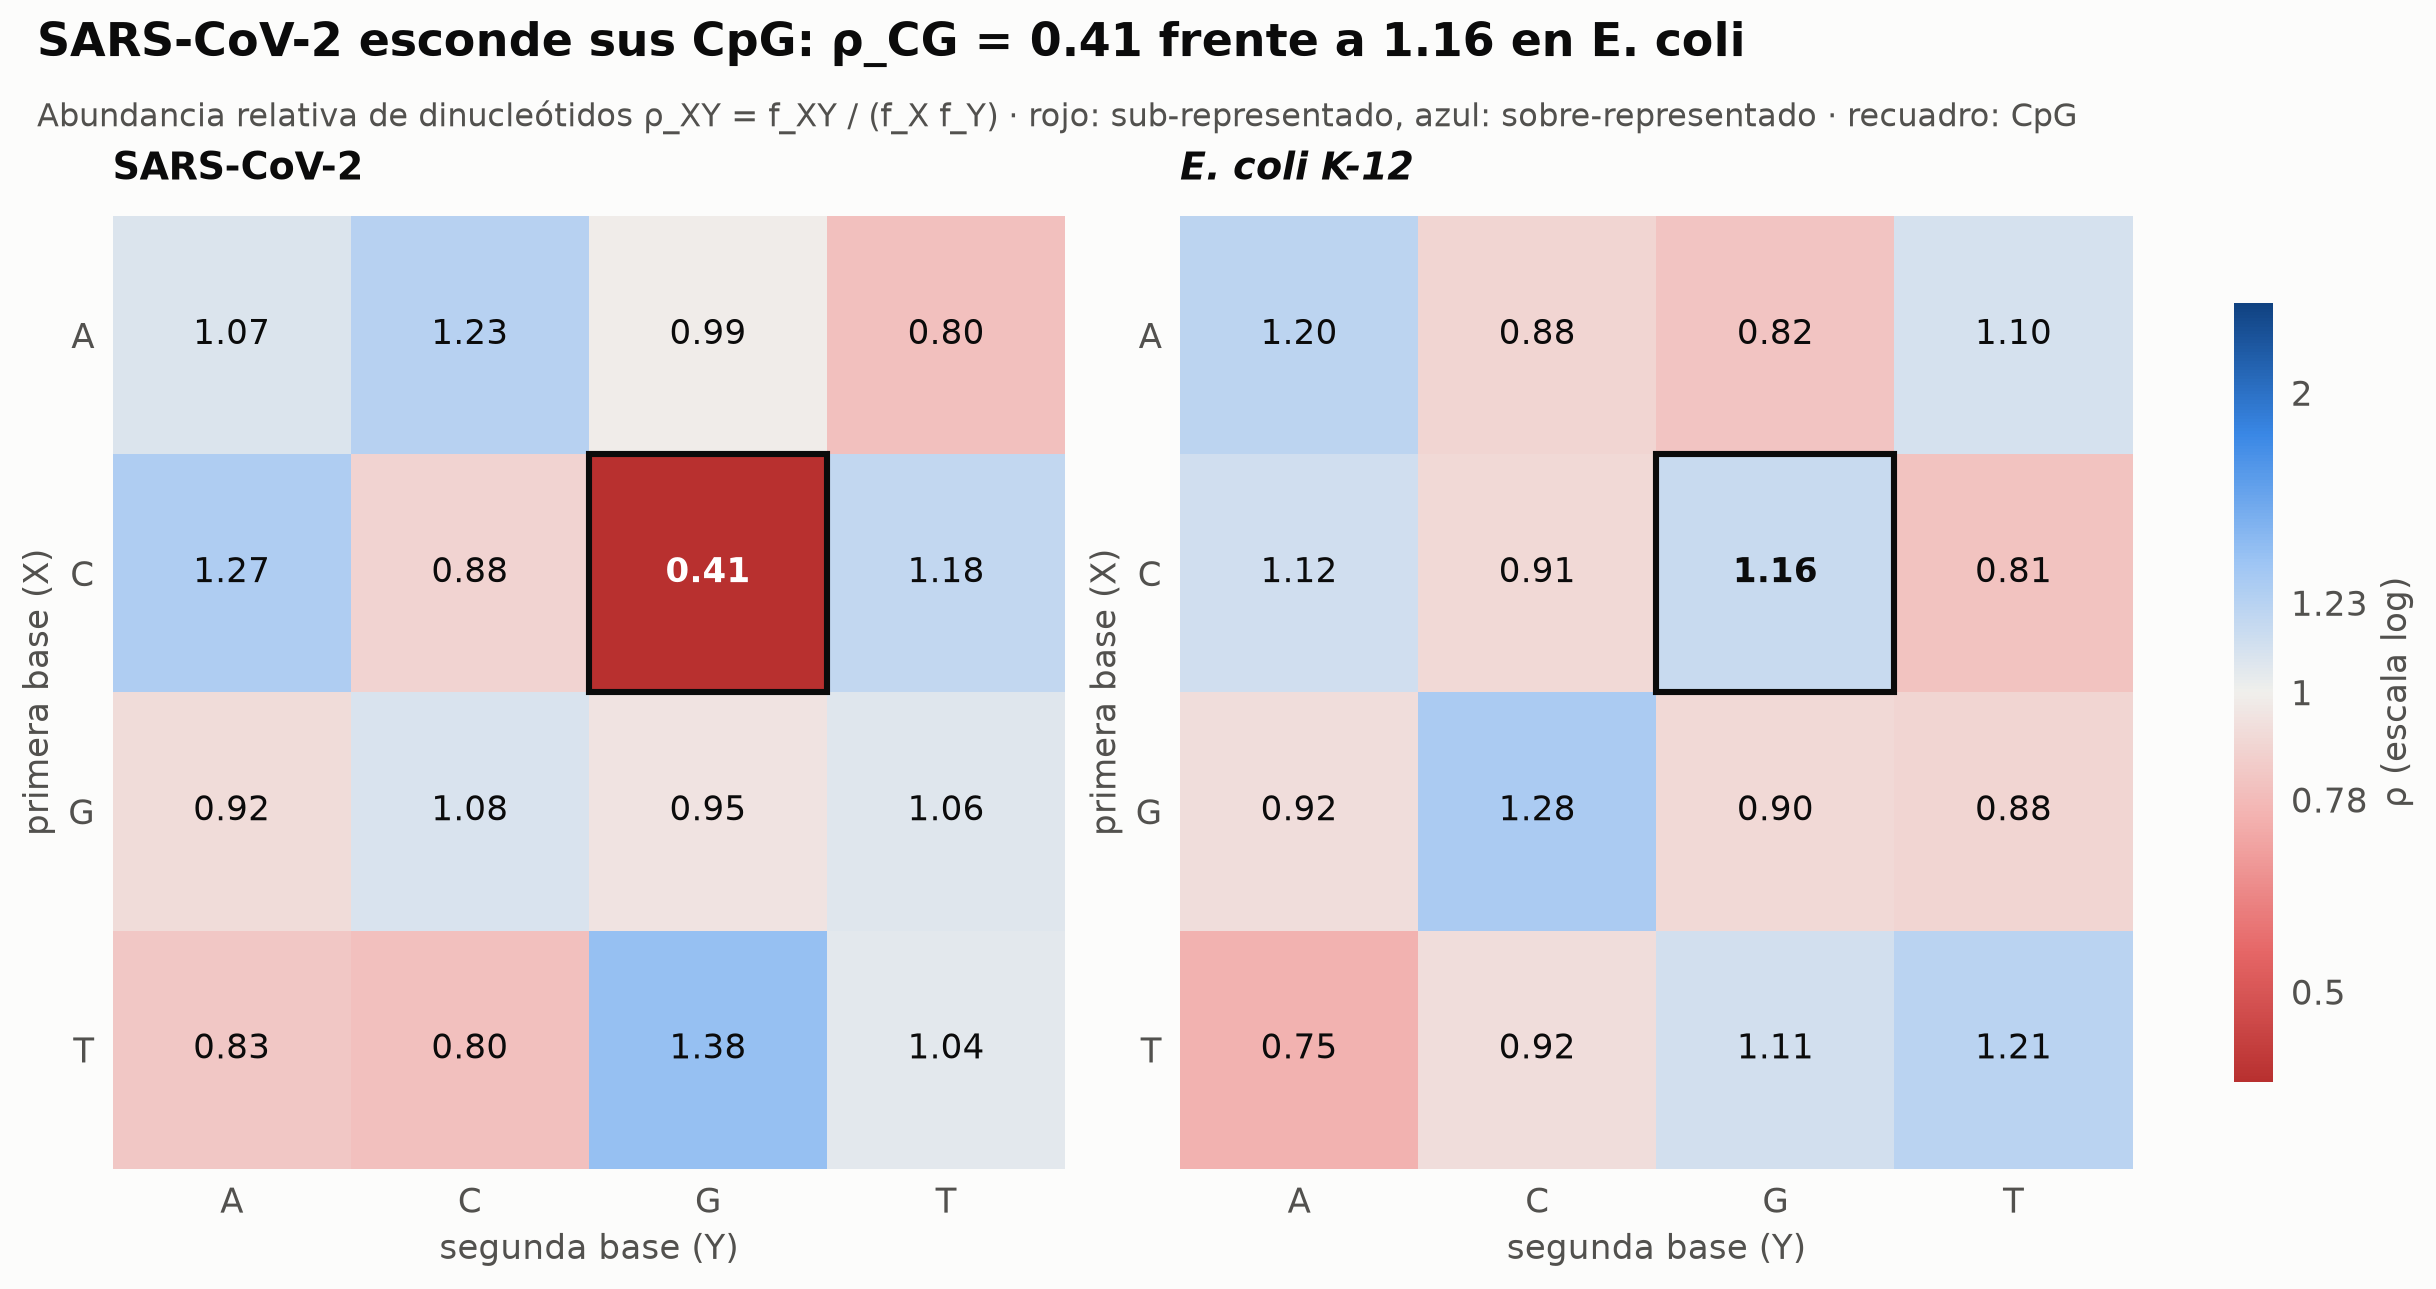

In [15]:
from matplotlib.colors import TwoSlopeNorm
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
norm = TwoSlopeNorm(vmin=-1.3, vcenter=0, vmax=1.3)
for ax, (name, m) in zip(axes, rho.items()):
    lr = np.log2(m.values)
    im = ax.imshow(lr, cmap=ec.CMAP_DIV.reversed(), norm=norm)
    for i in range(4):
        for j in range(4):
            v = m.values[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=11,
                    color="white" if abs(lr[i, j]) > 0.8 else ec.INK,
                    fontweight="bold" if (i, j) == (1, 2) else "normal")
    ax.set_xticks(range(4), list("ACGT")); ax.set_yticks(range(4), list("ACGT"))
    ax.set_xlabel("segunda base (Y)"); ax.set_ylabel("primera base (X)")
    ax.grid(False)
    for s in ax.spines.values(): s.set_visible(False)
    ax.set_title(name, loc="left", fontsize=12.5, style="italic" if "coli" in name else "normal")
    ax.add_patch(plt.Rectangle((1.5, 0.5), 1, 1, fill=False, ec=ec.INK, lw=2))
cb = fig.colorbar(im, ax=axes, shrink=0.8, ticks=np.log2([0.5, 0.78, 1, 1.23, 2]))
cb.ax.set_yticklabels(["0.5", "0.78", "1", "1.23", "2"]); cb.set_label("ρ (escala log)"); cb.outline.set_visible(False)
ec.fig_title(fig, f"SARS-CoV-2 esconde sus CpG: ρ_CG = {rho['SARS-CoV-2'].loc['C','G']:.2f} "
             f"frente a {rho['E. coli K-12'].loc['C','G']:.2f} en E. coli",
             "Abundancia relativa de dinucleótidos ρ_XY = f_XY / (f_X f_Y) · rojo: sub-representado, azul: sobre-representado · recuadro: CpG")
plt.show()

### 🖱️ Gráfico interactivo: observado contra esperado

Pase el cursor por cada celda: verá la frecuencia **observada**, la **esperada** y el cociente $\rho$. Compare el
dinucleótido **CG** en ambos genomas, y busque también **TA**: ¿está sub-representado en alguno?

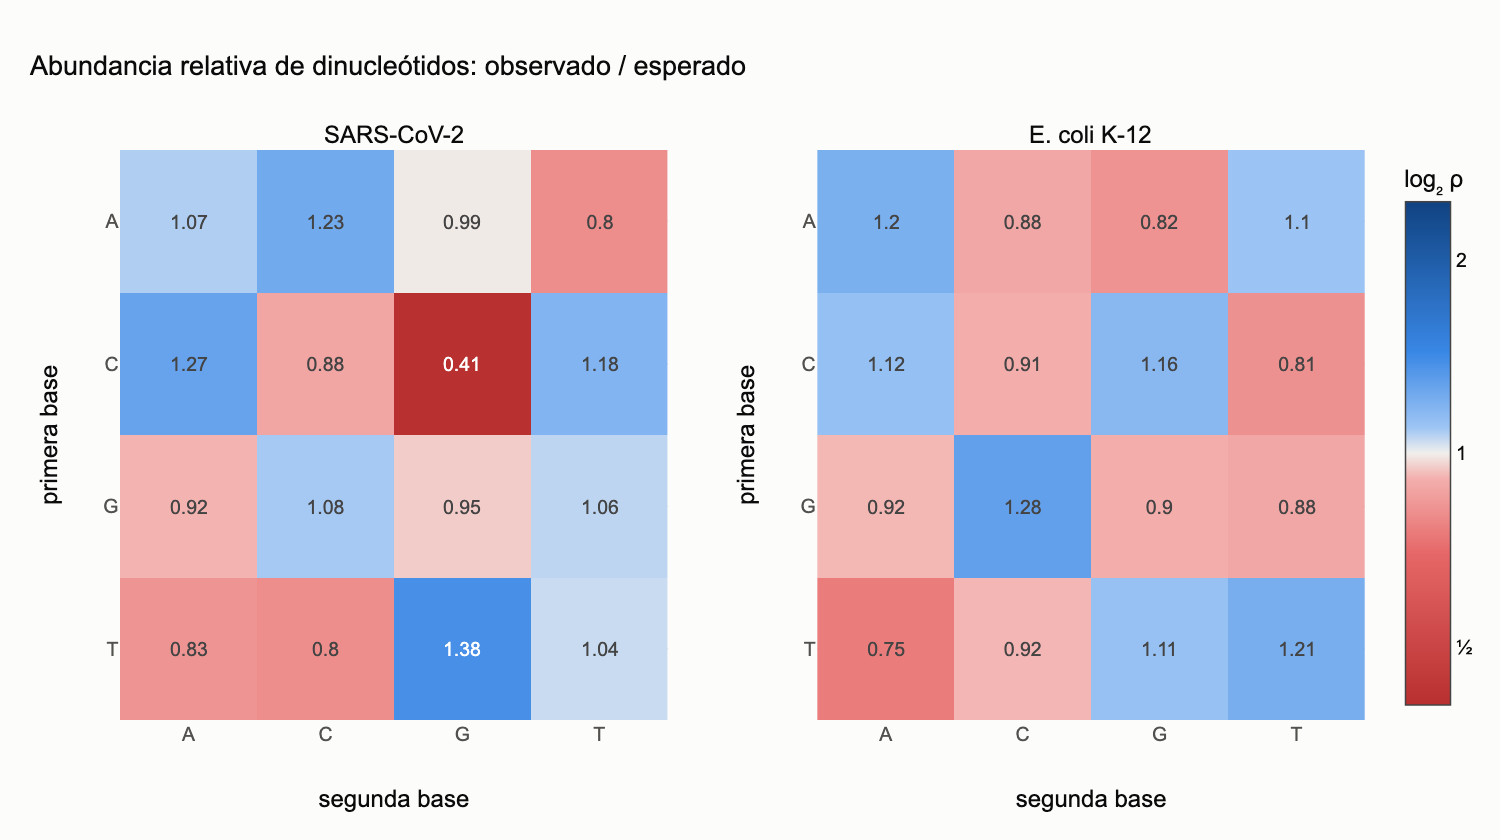

In [16]:
def dinuc_detail(seq):
    arr = np.frombuffer(seq.encode("ascii"), dtype=np.uint8)
    code = np.full(256, -1); code[[ord(b) for b in "ACGT"]] = range(4)
    idx = code[arr]; ok = (idx[:-1] >= 0) & (idx[1:] >= 0)
    pairs = np.bincount(idx[:-1][ok] * 4 + idx[1:][ok], minlength=16).reshape(4, 4)
    f_xy = pairs / pairs.sum()
    f_x = np.bincount(idx[idx >= 0], minlength=4) / (idx >= 0).sum()
    return f_xy, np.outer(f_x, f_x)

div_scale = [[0.0, "#b8302f"], [0.3, "#e66767"], [0.45, "#f3b0ae"], [0.5, "#f0efec"],
             [0.55, "#9ec5f4"], [0.7, "#3987e5"], [1.0, "#104281"]]
fig_h = make_subplots(rows=1, cols=2, subplot_titles=list(rho), horizontal_spacing=0.12)
for col, (name, seq) in enumerate([("SARS-CoV-2", str(sars.seq).upper()), ("E. coli K-12", ecoli_seq)], start=1):
    obs, exp = dinuc_detail(seq)
    r = obs / exp
    custom = np.dstack([obs * 100, exp * 100, r])
    fig_h.add_trace(go.Heatmap(
        z=np.log2(r), x=list("ACGT"), y=list("ACGT"), zmin=-1.3, zmax=1.3, colorscale=div_scale,
        customdata=custom, text=np.round(r, 2), texttemplate="%{text}", showscale=(col == 2),
        colorbar=dict(title="log₂ ρ", tickvals=[-1, 0, 1], ticktext=["½", "1", "2"]),
        hovertemplate=("<b>%{y}%{x}</b> (" + name + ")<br>observado: %{customdata[0]:.2f} %"
                       "<br>esperado: %{customdata[1]:.2f} %<br>ρ = %{customdata[2]:.2f}<extra></extra>")),
        row=1, col=col)
fig_h.update_yaxes(autorange="reversed", title_text="primera base")
fig_h.update_xaxes(title_text="segunda base", showgrid=False)
fig_h.update_layout(title=dict(text="Abundancia relativa de dinucleótidos: observado / esperado"), height=460)
fig_h.show()

🔎 **Qué observamos.** En SARS-CoV-2 el CpG aparece a menos de la mitad de lo esperado por azar, una de las
sub-representaciones más fuertes de toda la matriz. En *E. coli* el CpG **no** está suprimido ($\rho \approx 1.2$): las bacterias no
tienen la maquinaria de metilación de CpG de los vertebrados ni la presión de ZAP. Los dinucleótidos son una
**firma genómica**: dos fragmentos de ADN con matrices $\rho$ parecidas probablemente vienen de organismos
emparentados, una idea que se usa en metagenómica para agrupar fragmentos por especie (Módulo 14).

## ✍️ Ejercicios

**Ejercicio 1 — A mano y en código.** Calcule a mano el sesgo GC y el saldo acumulado final de `CCGTACGGGC`.
Verifique con `gc_skew` y `cumulative_skew`.

**Ejercicio 2 — El sesgo AT.** Defina $S_{AT} = (n_A - n_T)/(n_A + n_T)$ y calcúlelo en ventanas de 100 kb para
*E. coli*. ¿También cambia de signo en *oriC* y *ter*? ¿Es más fuerte o más débil que el sesgo GC?

**Ejercicio 3 — Verifique la anotación.** Descargue el GenBank completo de `NC_000913.3` (`rettype="gbwithparts"`,
≈ 11 MB) y extraiga las coordenadas del *feature* `rep_origin` y del gen `tus`. ¿Coinciden con las usadas en la
clase?

**Ejercicio 4 — Otra bacteria.** Repita el análisis del sesgo acumulado con *Bacillus subtilis* 168
(`NC_000964.3`). ¿Dónde cae el mínimo? (Pista: en muchos genomas bacterianos la numeración empieza justo en *oriC*
o en el gen *dnaA*.)

**Ejercicio 5 — Firmas de dinucleótidos.** ¿Cuál es el dinucleótido **más** sub-representado en cada genoma? ¿Y el
más sobre-representado?

In [17]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
s = "CCGTACGGGC"
# G: posiciones 3, 7, 8, 9 → 4 ; C: posiciones 1, 2, 6, 10 → 4  → S = 0/8 = 0 ; saldo final = 0
print("S =", gc_skew(s), "| saldo paso a paso:", cumulative_skew(s))

S = 0.0 | saldo paso a paso: [-1 -2 -1 -1 -1 -2 -1  0  1  0]


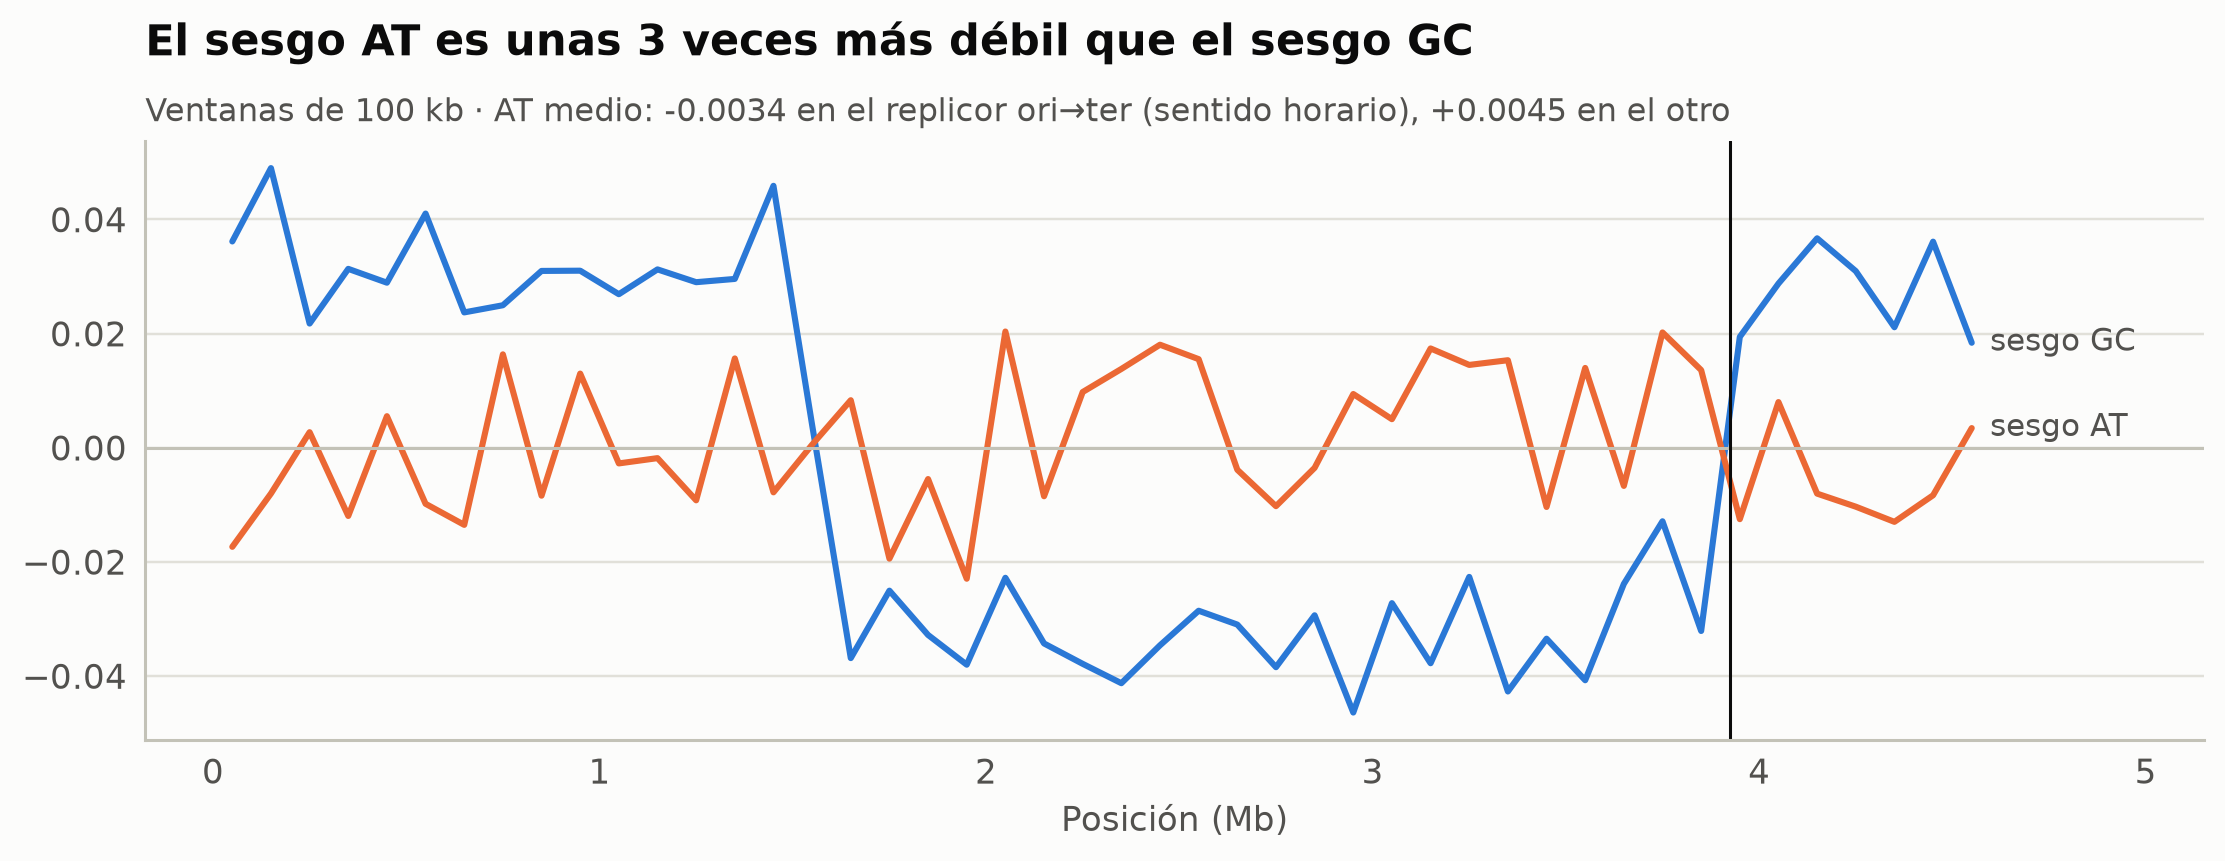

In [18]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
w = 100_000; n = L // w
a = np.frombuffer(ecoli_seq[: n * w].encode("ascii"), dtype=np.uint8).reshape(n, w)
A = (a == ord("A")).sum(1); T = (a == ord("T")).sum(1); G = (a == ord("G")).sum(1); C = (a == ord("C")).sum(1)
at_skew, gcs = (A - T) / (A + T), (G - C) / (G + C)
fig, ax = plt.subplots(figsize=(10, 3.8))
x = (np.arange(n) + 0.5) * w / 1e6
ax.plot(x, gcs, color=ec.BLUE, label="sesgo GC"); ax.plot(x, at_skew, color=ec.ORANGE, label="sesgo AT")
ax.axhline(0, color=ec.BASELINE, lw=1); ax.axvline(ori_mid / 1e6, color=ec.INK, lw=1)
ec.label_end(ax, x[-1], gcs[-1], "sesgo GC"); ec.label_end(ax, x[-1], at_skew[-1], "sesgo AT")
ax.set_xlim(right=x[-1] + 0.6); ax.set_xlabel("Posición (Mb)")
right_rep = (x * 1e6 < pred_ter) | (x * 1e6 > pred_ori)
ec.title(ax, f"El sesgo AT es unas {np.abs(gcs).mean() / np.abs(at_skew).mean():.0f} veces más débil que el sesgo GC",
         f"Ventanas de 100 kb · AT medio: {at_skew[right_rep].mean():+.4f} en el replicor ori→ter (sentido horario), "
         f"{at_skew[~right_rep].mean():+.4f} en el otro")
plt.show()

In [19]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
try:
    with Entrez.efetch(db="nuccore", id=ACC, rettype="gbwithparts", retmode="text") as h:
        full = SeqIO.read(h, "genbank")
    for f in full.features:
        if f.type == "rep_origin" or (f.type == "gene" and f.qualifiers.get("gene") == ["tus"]):
            print(f.type, f.qualifiers.get("note", f.qualifiers.get("gene")), int(f.location.start) + 1, "–", int(f.location.end))
except Exception as err:
    print("No se pudo descargar (ejecute en Colab con internet):", err)

gene ['tus'] 1684259 – 1685188
rep_origin ['oriC'] 3925744 – 3925975


B. subtilis: 4,215,606 pb · mínimo del saldo en 4,215,596 · máximo en 1,942,437


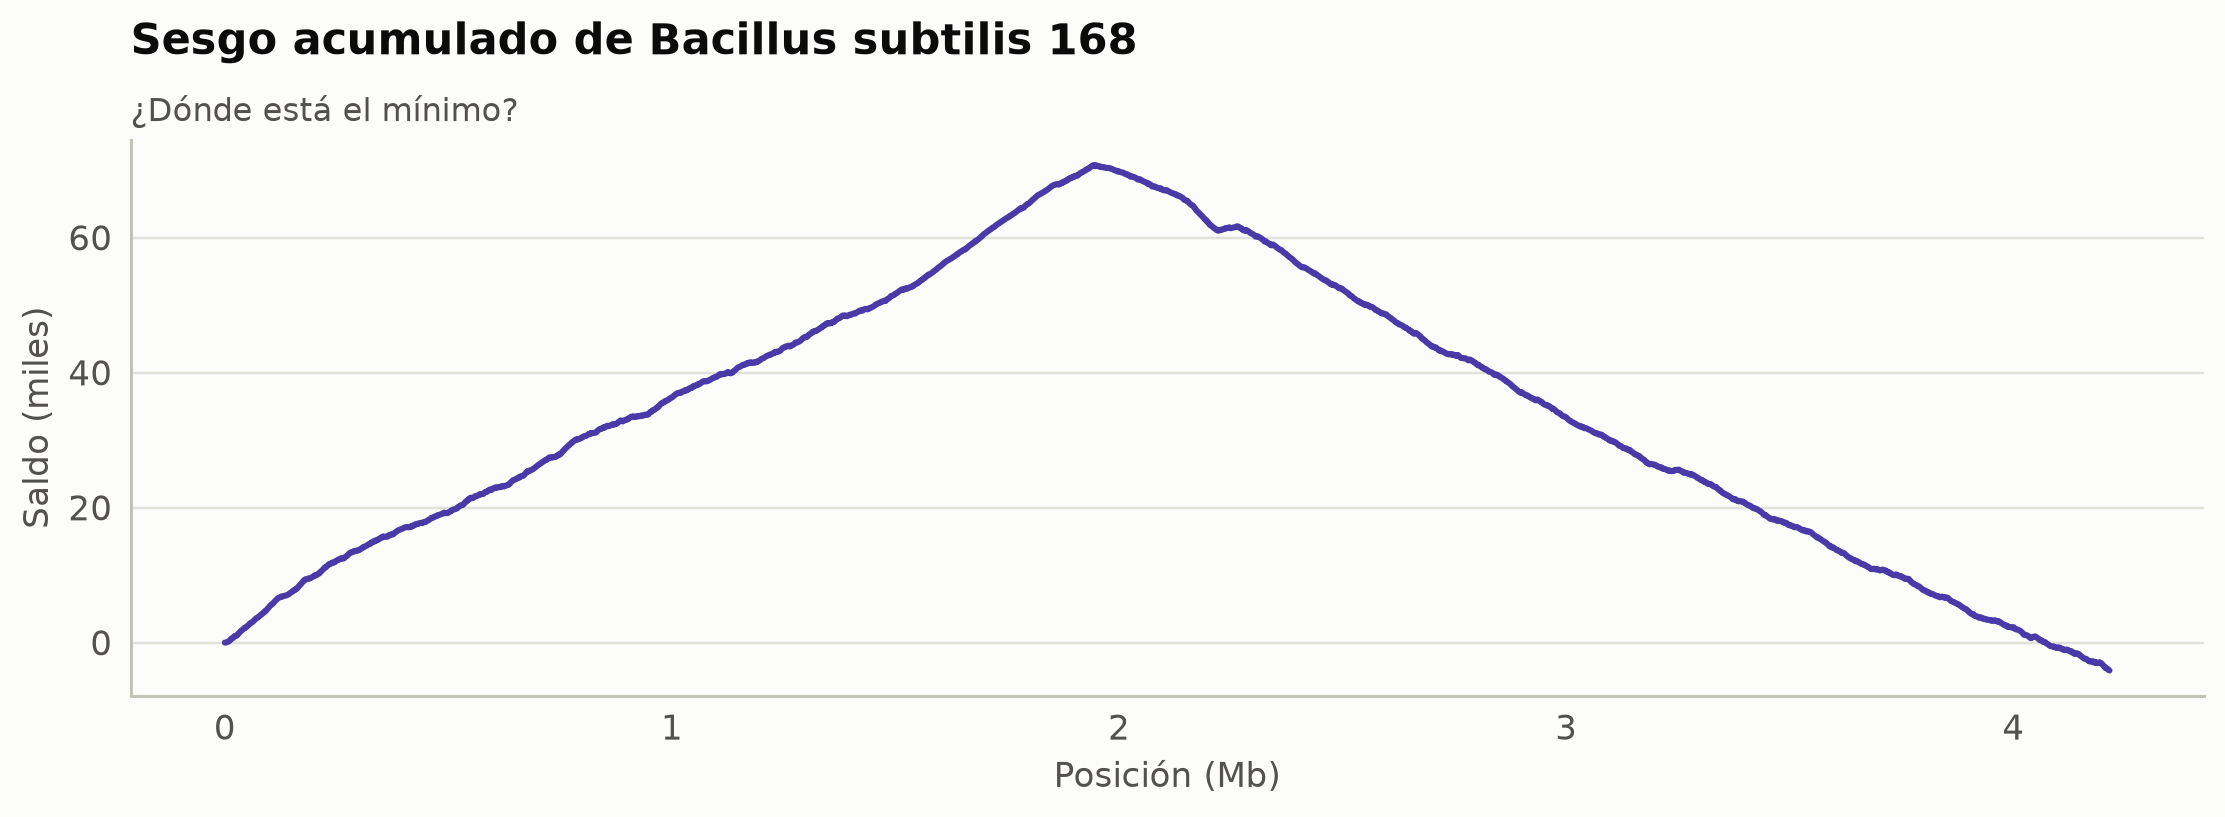

In [20]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
try:
    with Entrez.efetch(db="nuccore", id="NC_000964.3", rettype="fasta", retmode="text") as h:
        bsub = str(SeqIO.read(h, "fasta").seq).upper()
    cs_b = cumulative_skew(bsub)
    print(f"B. subtilis: {len(bsub):,} pb · mínimo del saldo en {np.argmin(cs_b)+1:,} · máximo en {np.argmax(cs_b)+1:,}")
    fig, ax = plt.subplots(figsize=(10, 3.6))
    ax.plot(np.arange(0, len(bsub), 1000) / 1e6, cs_b[::1000] / 1000, color=ec.VIOLET)
    ax.set_xlabel("Posición (Mb)"); ax.set_ylabel("Saldo (miles)")
    ec.title(ax, "Sesgo acumulado de Bacillus subtilis 168", "¿Dónde está el mínimo?")
    plt.show()
except Exception as err:
    print("No se pudo descargar (ejecute en Colab con internet):", err)

In [21]:
#@title 🔑 Solución — Ejercicio 5 { display-mode: "form" }
for name, m in rho.items():
    s = m.stack()
    print(f"{name:13s} más sub-representado: {''.join(s.idxmin())} (ρ={s.min():.2f}) · "
          f"más sobre-representado: {''.join(s.idxmax())} (ρ={s.max():.2f})")

SARS-CoV-2    más sub-representado: CG (ρ=0.41) · más sobre-representado: TG (ρ=1.38)
E. coli K-12  más sub-representado: TA (ρ=0.75) · más sobre-representado: GC (ρ=1.28)


## 📌 Resumen

* El cromosoma bacteriano circular se copia desde **oriC** con **dos horquillas** que se encuentran en **ter**;
  cada mitad es un **replicor**.
* La ADN polimerasa sólo sintetiza 5'→3': una hebra se copia **de corrido** (adelantada) y la otra en
  **fragmentos de Okazaki** (retrasada). El molde de la retrasada queda expuesto como cadena sencilla.
* La desaminación C → T, más frecuente en cadena sencilla, deja una **cicatriz**: el **sesgo GC**
  $S = (G-C)/(G+C)$ cambia de signo en *oriC* y *ter*.
* El **sesgo acumulado** (un saldo bancario de G y C) tiene su **mínimo en oriC** y su **máximo en ter**; con él
  ubicamos el origen de *E. coli* a pocas kb de su posición anotada.
* El ruido del sesgo en una ventana es $1/\sqrt{m}$: el tamaño de ventana es una decisión **estadística**.
* La abundancia de dinucleótidos $\rho_{XY} = f_{XY}/(f_X f_Y)$ es una firma genómica; SARS-CoV-2 **suprime los
  CpG**.

**Próximo módulo (2):** secuencias, formatos y bases de datos.

## 📚 Para profundizar

* Lobry, J. R. (1996). Asymmetric substitution patterns in the two DNA strands of bacteria.
  *Molecular Biology and Evolution* 13(5): 660–665.
* Frank, A. C. & Lobry, J. R. (1999). Asymmetric substitution patterns: a review of possible underlying mutational
  or selective mechanisms. *Gene* 238(1): 65–77.
* Grigoriev, A. (1998). Analyzing genomes with cumulative skew diagrams. *Nucleic Acids Research* 26(10): 2286–2290.
* Karlin, S. & Burge, C. (1995). Dinucleotide relative abundance extremes: a genomic signature.
  *Trends in Genetics* 11(7): 283–290.
* Takata, M. A. *et al.* (2017). CG dinucleotide suppression enables antiviral defence targeting non-self RNA.
  *Nature* 550: 124–127.

---

☕ **¿Le sirvió esta clase?** El curso es gratuito y seguirá siéndolo; puede apoyarlo invitándome un café en [buymeacoffee.com/juvenalyosx](https://buymeacoffee.com/juvenalyosx). ¡Gracias!

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Apoye el proyecto: Buy Me a Coffee](https://img.shields.io/badge/Apoye%20el%20proyecto-Buy%20Me%20a%20Coffee-FFDD00?logo=buymeacoffee&logoColor=black)](https://buymeacoffee.com/juvenalyosx)